<a href="https://colab.research.google.com/github/abdelrhman744/football-analysis/blob/main/Untitled22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="TbvOFjnrRQx70jrS0c36") #put your api key
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(12)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-12 in yolov11:: 100%|██████████| 756/756 [00:00<00:00, 1585.15it/s]


In [13]:
import cv2
import random
import glob as glob
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

In [ ]:
def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2] / 2, bboxes[1] - bboxes[3] / 2
    xmax, ymax = bboxes[0]+bboxes[2] / 2, bboxes[1] + bboxes[3] / 2
    return xmin, ymin, xmax, ymax

In [ ]:
class_names = ['ball', 'goalkeeper', 'player', 'referee']
colors = np.random.uniform(0, 255, size=(len(class_names), 3))

def plot_box(image, bboxes, labels):
    # Need the image height and width to denormalize
    # the bounding box coordinates
    h, w, _ = image.shape
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolo2bbox(box)

        # denormalize the coordinates
        xmin = int(x1 * w)
        ymin = int(y1 * h)
        xmax = int(x2 * w)
        ymax = int(y2 * h)
        width = xmax - xmin
        height = ymax - ymin

        class_name = class_names[int(labels[box_num])]

        cv2.rectangle(
            image,
            (xmin, ymin), (xmax, ymax),
            color=colors[class_names.index(class_name)],
            thickness=2
        )

        font_scale = min(1,max(3,int(w/500)))
        font_thickness = min(2, max(10,int(w/50)))

        p1, p2 = (int(xmin), int(ymin)), (int(xmax), int(ymax))

        # Text width and height
        tw, th = cv2.getTextSize(class_name, 0, fontScale=font_scale, thickness=font_thickness)[0]
        p2 = p1[0] + tw, p1[1] + -th - 10
        cv2.rectangle(
            image,
            p1, p2,
            color=colors[class_names.index(class_name)],
            thickness=-1,
        )
        cv2.putText(
            image,
            class_name,
            (xmin+1, ymin-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 255, 255),
            font_thickness
        )
    return image

In [ ]:
# Function to plot images with the bounding boxes.
def plot(image_paths, label_paths, num_samples):
    all_training_images = glob.glob(image_paths)
    all_training_labels = glob.glob(label_paths)
    all_training_images.sort()
    all_training_labels.sort()

    num_images = len(all_training_images)

    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        j = random.randint(0,num_images-1)
        image = cv2.imread(all_training_images[j])
        with open(all_training_labels[j], 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label = label_line[0]
                bbox_string = label_line[2:]
                x_c, y_c, w, h = bbox_string.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')
    plt.subplots_adjust(wspace=0)
    plt.tight_layout()
    plt.show()

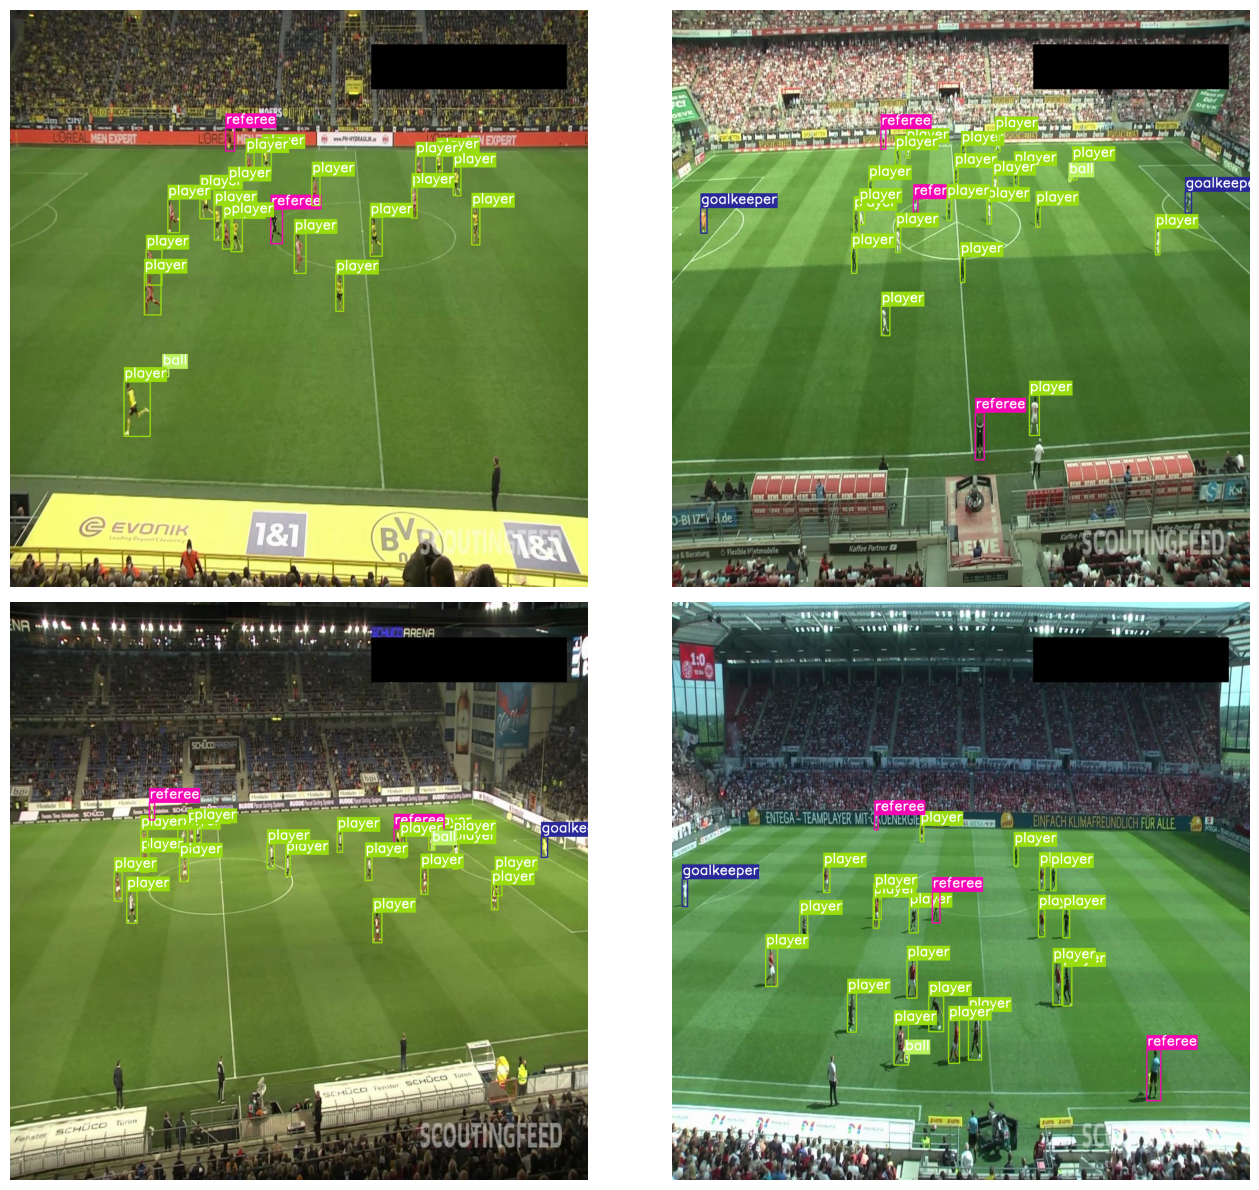

In [ ]:
plot(image_paths='/content/football-players-detection-12/train/images/*',
    label_paths='/content/football-players-detection-12/train/labels/*',
    num_samples=4,
)

In [14]:
!pip install ultralytics

In [15]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11s model
model = YOLO("yolo26m.pt")

In [ ]:
# Use the model
results = model.train(data="/content/football-players-detection-12/data.yaml", epochs=100)  # train the model

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [ ]:
!yolo task=detect mode=predict model=/content/best_player_referee.pt source='/content/football-players-detection-12/test/images/42ba34_1_5_png.rf.927d602c034ce2997f58f62a7c1245ba.jpg'

Ultralytics 8.4.88 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs

image 1/1 /content/football-players-detection-12/test/images/42ba34_1_5_png.rf.927d602c034ce2997f58f62a7c1245ba.jpg: 640x640 1 ball, 1 goalkeeper, 20 players, 2 referees, 37.8ms
Speed: 6.5ms preprocess, 37.8ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
img_path = '/content/runs/detect/predict/08fd33_3_6_png.rf.bee65249830b3e263ebe95a999f39e34.jpg'
img = plt.imread(img_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis(False)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict/08fd33_3_6_png.rf.bee65249830b3e263ebe95a999f39e34.jpg'

In [ ]:
!yolo task=detect mode=predict model=/content/best_player_referee.pt source='/content/Kvaratskhelia Opens The Score ｜ Lens 0-2 PSG ｜ Fir_1080p.mp4'

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 5, in <module>
    from ultralytics.cfg import entrypoint
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/__init__.py", line 13, in <module>
    from ultralytics.utils import ASSETS, SETTINGS
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py", line 26, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2229, in <module>
    from torch import _VF as _VF, functional as functional  # usort: skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/functional.py", line 8, in <module>
    import torch.nn.functional as F
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/__init__.py", line 8, in <module>
    from torch.nn.modules import *  # usort: skip # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/__in

In [16]:
import cv2
import numpy as np
from ultralytics import YOLO

In [17]:
model = YOLO(
"/content/best_player_referee.pt"
)

video = cv2.VideoCapture(
"/content/FULL MATCH ｜ Man City v Tottenham ｜ VIP Tactical C_1080p.webm"
)

In [18]:
while True:

    ret, frame = video.read()

    if not ret:
        break

    results = model(frame)

In [19]:
for box in results[0].boxes:

    cls = int(box.cls[0])

    label = model.names[cls]

    if label != "player":
        continue

NameError: name 'results' is not defined

In [ ]:
video.release()

video = cv2.VideoCapture("/content/drive/MyDrive/best weights/Quick passing 😮_💨🤩_854p.mp4")

In [ ]:
video = cv2.VideoCapture("/content/drive/MyDrive/best weights/Quick passing 😮_💨🤩_854p.mp4")

print(video.get(
cv2.CAP_PROP_FRAME_COUNT
))

514.0


In [ ]:
while True:
    ret, frame = video.read()

    if not ret:
        break  # ✅ صح هنا

    # مثال: لو عندك detection
    if box is not None:
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # حماية من الـ out of bounds
        h, w, _ = frame.shape
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        player = frame[y1:y2, x1:x2]

video.release()


🎬 Frame 1

0: 640x384 7 players, 30.4ms
Speed: 4.9ms preprocess, 30.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 384)
→ detected: player
✅ showing jersey


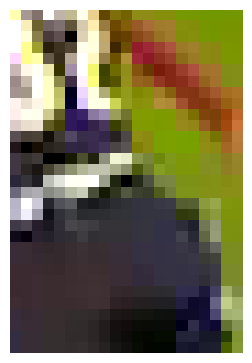

→ detected: player
✅ showing jersey


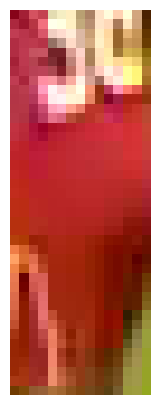

→ detected: player
✅ showing jersey


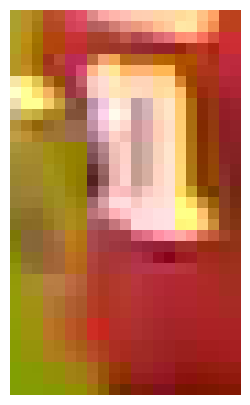

→ detected: player
✅ showing jersey


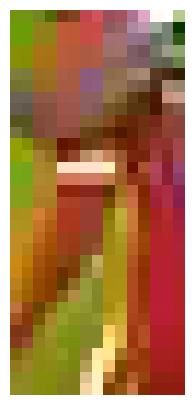

→ detected: player
✅ showing jersey


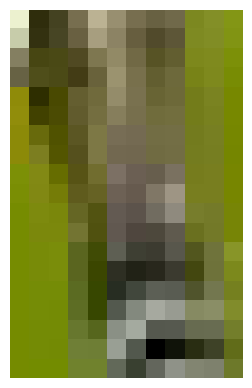

→ detected: player
✅ showing jersey


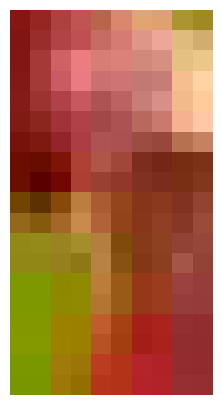

→ detected: player
✅ showing jersey


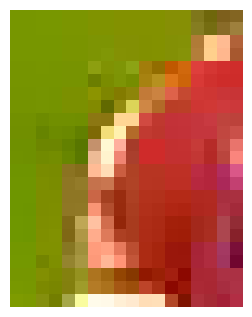


🎬 Frame 2

0: 640x384 5 players, 31.6ms
Speed: 7.5ms preprocess, 31.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
→ detected: player
✅ showing jersey


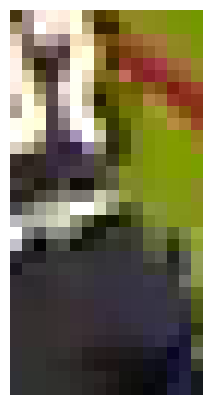

→ detected: player
✅ showing jersey


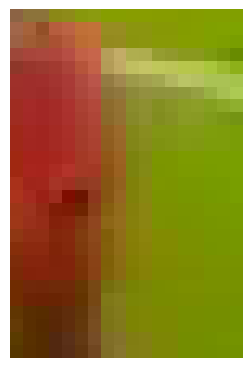

→ detected: player
✅ showing jersey


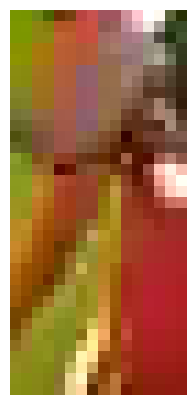

→ detected: player
✅ showing jersey


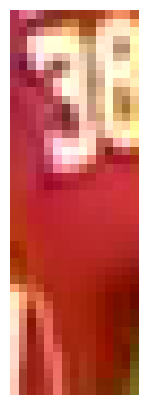

→ detected: player
✅ showing jersey


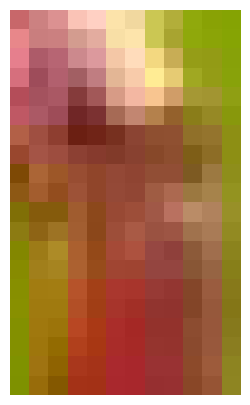


🎬 Frame 3

0: 640x384 4 players, 24.9ms
Speed: 6.8ms preprocess, 24.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
→ detected: player
✅ showing jersey


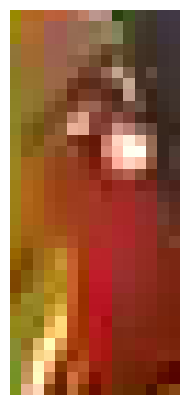

→ detected: player
✅ showing jersey


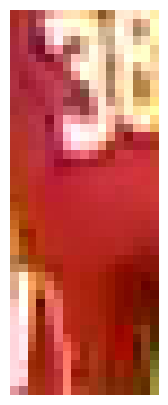

→ detected: player
✅ showing jersey


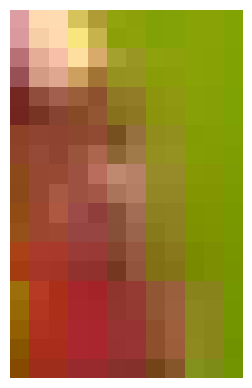

→ detected: player
✅ showing jersey


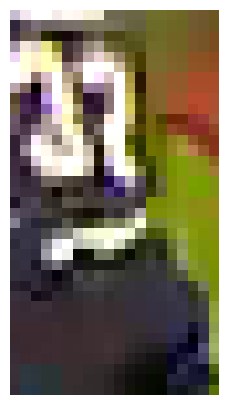


🎬 Frame 4

0: 640x384 3 players, 24.9ms
Speed: 6.9ms preprocess, 24.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
→ detected: player
✅ showing jersey


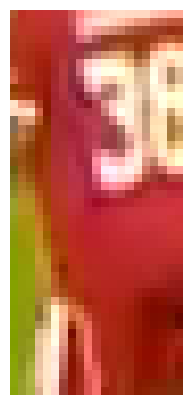

→ detected: player
✅ showing jersey


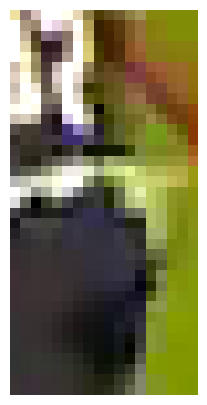

→ detected: player
✅ showing jersey


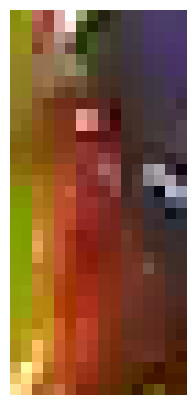


🎬 Frame 5

0: 640x384 4 players, 24.8ms
Speed: 7.2ms preprocess, 24.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)
→ detected: player
✅ showing jersey


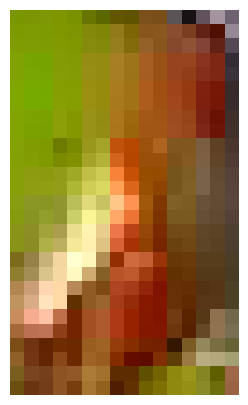

→ detected: player
✅ showing jersey


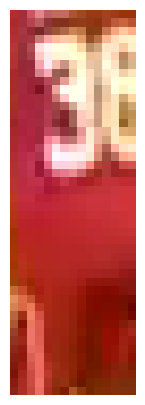

→ detected: player
✅ showing jersey


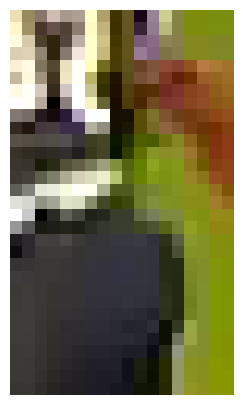

→ detected: player
✅ showing jersey


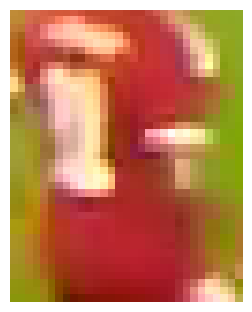

In [ ]:
import cv2
import matplotlib.pyplot as plt

video = cv2.VideoCapture("/content/drive/MyDrive/best weights/Quick passing 😮_💨🤩_854p.mp4")

frame_count = 0

while True:
    ret, frame = video.read()

    if not ret:
        break

    frame_count += 1
    print(f"\n🎬 Frame {frame_count}")

    results = model(frame)

    for box in results[0].boxes:

        cls = int(box.cls[0])
        name = model.names[cls]

        print("→ detected:", name)

        if name != "player":
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        h, w, _ = frame.shape
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        player = frame[y1:y2, x1:x2]

        if player.size == 0:
            print("❌ empty player crop")
            continue

        h, w = player.shape[:2]

        jersey = player[
            int(h*0.2):int(h*0.6),
            int(w*0.2):int(w*0.8)
        ]

        if jersey.size == 0:
            print("❌ empty jersey")
            continue

        print("✅ showing jersey")

        plt.figure(figsize=(3,5))
        plt.imshow(cv2.cvtColor(jersey, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    if frame_count == 5:  # جرب أول 5 فريمات بس
        break

video.release()

In [ ]:
print(frame.shape)
print(model.names)
print(len(results[0].boxes))

(854, 480, 3)
{0: 'ball', 1: 'goalkeeper', 2: 'player', 3: 'referee'}
4


**Note:** the diagnostic cell below tested the *old combined 4-class model*
and is what originally proved the penalty-spot bug. It's kept here for
reference/comparison only — it is **not** part of the active pipeline anymore.
The new sanity-check cell further down tests the new dedicated ball model
the same way.

In [ ]:
# ============================================================
# 🔍 DIAGNOSTIC — Ball detection isolation test (read-only, no side effects)
# ============================================================
# Goal: find out WHERE the ball is being lost, WITHOUT touching the
# main pipeline (next cell) or anything downstream of it.
#
# This checks THREE separate things:
#   1) Does the model even have a 'ball' class, and at what index?
#   2) At the model's usual confidence (0.25), how many raw 'ball'
#      detections happen across the whole clip?
#   3) At a much lower confidence (0.01), how many raw 'ball'
#      detections happen?
#
#   If (3) >> (2)  → the model DOES see the ball, just below the
#                     default confidence threshold. That's a config
#                     fix (lower conf for ball class), not a
#                     retrain-from-scratch problem.
#   If (3) == 0     → the model genuinely never finds the ball in
#                     this clip at ANY confidence. That confirms the
#                     problem is the detector itself (resolution /
#                     training data) → YOLO26 ball-detector retrain
#                     is the right next step.
#
# Uses model.predict() directly (NOT model.track()) — no tracker,
# no SimpleBallTracker, no smoothing. Pure raw detection counts only,
# so the result can't be muddied by tracker-rejection logic.
# ============================================================

import os
import cv2
from collections import Counter
from ultralytics import YOLO

MODEL_PATH = "/content/best_player_referee.pt"
VIDEO_PATH = "/content/drive/MyDrive/best weights/Quick passing 😮_💨🤩_854p.mp4"

model_diag = YOLO(MODEL_PATH)
print("Class map:", model_diag.names)

ball_class_id = None
for idx, name in model_diag.names.items():
    if name == "ball":
        ball_class_id = idx

if ball_class_id is None:
    print("\n🛑 'ball' is not in model.names at all — this model literally")
    print("   cannot output a ball class. Skipping the rest of the diagnostic.")
else:
    print(f"'ball' class id = {ball_class_id}\n")

    CONF_LEVELS = [0.25, 0.10, 0.05, 0.01]
    LOWEST_CONF = min(CONF_LEVELS)
    counts = {c: 0 for c in CONF_LEVELS}
    confidences_seen = []
    sample_hits = []   # (frame_idx, frame, x1,y1,x2,y2, conf) — first 5 hits at lowest conf

    video = cv2.VideoCapture(VIDEO_PATH)
    fi = 0
    while True:
        ret, frame = video.read()
        if not ret:
            break

        # Run inference ONCE at the lowest threshold, bucket upward —
        # avoids re-running the model 4x per frame.
        results = model_diag.predict(frame, conf=LOWEST_CONF, verbose=False)

        for box in results[0].boxes:
            cls = int(box.cls[0])
            if cls != ball_class_id:
                continue
            conf = float(box.conf[0])
            confidences_seen.append(conf)
            for c in CONF_LEVELS:
                if conf >= c:
                    counts[c] += 1
            if len(sample_hits) < 5:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                sample_hits.append((fi, frame.copy(), x1, y1, x2, y2, conf))

        fi += 1

    video.release()

    print(f"Frames scanned: {fi}\n")
    print("Raw 'ball' detections at each confidence threshold:")
    for c in CONF_LEVELS:
        print(f"  conf >= {c:.2f} : {counts[c]:4d} detections  "
              f"({100*counts[c]/max(fi,1):.1f}% of frames)")

    if confidences_seen:
        print(f"\nConfidence stats over {len(confidences_seen)} raw hits (conf>=0.01):")
        print(f"  min={min(confidences_seen):.3f}  "
              f"max={max(confidences_seen):.3f}  "
              f"avg={sum(confidences_seen)/len(confidences_seen):.3f}")

        if counts[0.01] > counts[0.25] * 1.5:
            print("\n✅  DIAGNOSIS: the model DOES see the ball — mostly at LOW")
            print("    confidence. Lowering the conf threshold for ball-class")
            print("    detection (or boosting ball recall in training) should")
            print("    fix most of this WITHOUT a full retrain.")
        else:
            print("\n⚠️  DIAGNOSIS: detections exist but confidence is fairly")
            print("    consistent across thresholds — the rare hits found are")
            print("    real, not just a thresholding issue.")
    else:
        print("\n🛑 ZERO ball detections even at conf>=0.01.")
        print("   The model never finds the ball in this clip, at ANY confidence.")
        print("   → This points to the DETECTOR itself (resolution / training")
        print("     data quality for the ball class), not the tracker/filtering")
        print("     logic downstream. Confirms the YOLO26 ball-detector retrain")
        print("     (higher res, dedicated Roboflow ball dataset) is the right")
        print("     next step — no point tuning SimpleBallTracker first.")

    # ── Save a few low-confidence sample crops so you can eyeball them ───────
    if sample_hits:
        crop_dir = "/content/ball_diag_crops"
        os.makedirs(crop_dir, exist_ok=True)
        print(f"\nSaving {len(sample_hits)} sample crops to {crop_dir} ...")
        pad = 30
        for fi_s, frm, x1, y1, x2, y2, conf in sample_hits:
            h, w = frm.shape[:2]
            cx1, cy1 = max(0, x1 - pad), max(0, y1 - pad)
            cx2, cy2 = min(w, x2 + pad), min(h, y2 + pad)
            crop = frm[cy1:cy2, cx1:cx2]
            out_path = f"{crop_dir}/frame{fi_s}_conf{conf:.2f}.jpg"
            cv2.imwrite(out_path, crop)
            print(f"  {out_path}")


Class map: {0: 'ball', 1: 'goalkeeper', 2: 'player', 3: 'referee'}
'ball' class id = 0

Frames scanned: 514

Raw 'ball' detections at each confidence threshold:
  conf >= 0.25 :   69 detections  (13.4% of frames)
  conf >= 0.10 :  152 detections  (29.6% of frames)
  conf >= 0.05 :  269 detections  (52.3% of frames)
  conf >= 0.01 :  806 detections  (156.8% of frames)

Confidence stats over 806 raw hits (conf>=0.01):
  min=0.010  max=0.665  avg=0.077

✅  DIAGNOSIS: the model DOES see the ball — mostly at LOW
    confidence. Lowering the conf threshold for ball-class
    detection (or boosting ball recall in training) should
    fix most of this WITHOUT a full retrain.

Saving 5 sample crops to /content/ball_diag_crops ...
  /content/ball_diag_crops/frame0_conf0.04.jpg
  /content/ball_diag_crops/frame1_conf0.02.jpg
  /content/ball_diag_crops/frame1_conf0.01.jpg
  /content/ball_diag_crops/frame2_conf0.01.jpg
  /content/ball_diag_crops/frame4_conf0.01.jpg


---
## 🎯 Dedicated Ball-Only Detection Model

The combined 4-class model above (`ball, goalkeeper, player, referee`) is what
was misidentifying the penalty-spot marking as the ball. The cells below train
a **second, single-class model** ("ball" only) on a dataset that contains
*nothing but ball annotations* — no player/referee boxes to share decision
boundaries with, and the dataset itself (`football-ball-detection-rejhg`) is
the official ball-only companion to the player dataset you already used above
(same Roboflow workspace: `roboflow-jvuqo`).

This model becomes **Model 2** in the pipeline below. Model 1 (the original
4-class model) is still used, but only for `player` / `goalkeeper` / `referee`
— its `ball` class output is ignored completely from this point on.


In [ ]:
# ============================================================
# ⚽ BALL-ONLY DATASET — Roboflow download
# ============================================================
# Dataset : roboflow-jvuqo/football-ball-detection-rejhg  (v2)
# This is the official "ball-only" companion dataset to the
# football-players-detection-3zvbc set used above (same Roboflow
# workspace, published by Roboflow themselves, used directly in
# Roboflow's own "sports" reference repo for soccer ball detection).
# Single class: "ball". No other classes at all — so the model can't
# learn to confuse ball with anything else the way the combined
# 4-class model did.
# ============================================================
from roboflow import Roboflow



rf_ball = Roboflow(api_key="thzGMRXlN7mSRqFWr4Rk")

ball_project = rf_ball.workspace("roboflow-jvuqo").project("football-ball-detection-rejhg")
ball_version = ball_project.version(2)          # v2 = 4948 images, single 'ball' class
ball_dataset = ball_version.download("yolo26")

print("✅ Ball dataset downloaded to:", ball_dataset.location)


loading Roboflow workspace...
loading Roboflow project...
✅ Ball dataset downloaded to: /content/football-ball-detection-2


In [ ]:
# ============================================================
# 🔧 Fix data.yaml paths + verify it's really single-class "ball"
# ============================================================
# Roboflow's default data.yaml paths are sometimes relative in a way
# that doesn't match where ultralytics expects to find images when
# running from /content. Point them at the real folders explicitly,
# and assert the dataset is what we think it is before burning GPU
# time training against the wrong thing.
# ============================================================
import yaml

yaml_path = f"{ball_dataset.location}/data.yaml"
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

data_cfg['train'] = f"{ball_dataset.location}/train/images"
data_cfg['val']   = f"{ball_dataset.location}/valid/images"
data_cfg['test']  = f"{ball_dataset.location}/test/images"

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f)

print("Classes:", data_cfg['names'])
print("nc:", data_cfg['nc'])
assert data_cfg['nc'] == 1 and data_cfg['names'][0] == 'ball', (
    "⚠️ Expected a single 'ball' class — if this fails, the dataset "
    "version changed upstream or downloaded wrong. Check "
    "https://universe.roboflow.com/roboflow-jvuqo/football-ball-detection-rejhg "
    "before continuing."
)
print("✅ data.yaml verified — single-class ball dataset confirmed")


Classes: ['ball']
nc: 1
✅ data.yaml verified — single-class ball dataset confirmed


In [ ]:
# ============================================================
# ⚽ TRAIN — dedicated ball-only model
# ============================================================
# Model choice: yolo11s (small), not yolo11x.
#   - yolo11x is more accurate but ~5-8x slower to train AND to run
#     at inference time — and you're about to run TWO models per
#     frame, so inference cost matters twice as much now.
#   - yolo11s trains in a fraction of the time on a Colab/Kaggle T4
#     and is plenty of capacity for a single, simple class like "ball".
# imgsz=960 (not 1280): keeps train+infer time reasonable while still
# giving the small ball enough resolution to be visible. If there's
# time left after this works end-to-end, retraining with yolo11x /
# imgsz=1280 is the natural next accuracy upgrade — but get the
# pipeline working correctly first.
# ============================================================
from ultralytics import YOLO

ball_model_base = YOLO("yolo26m.pt")

ball_train_results = ball_model_base.train(
    data       = yaml_path,
    epochs     = 60,
    imgsz      = 1280,
    batch      = 16,
    patience   = 15,     # early stop if val mAP doesn't improve for 15 epochs
    project    = "/content/runs/ball_detect",
    name       = "train",
    single_cls = True,   # explicit, even though there's only one class anyway
)

BALL_MODEL_PATH = "/content/best_ball.pt"
print("✅ Ball model trained →", BALL_MODEL_PATH)


New https://pypi.org/project/ultralytics/8.4.87 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-ball-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, mul

# التشغيل من اول هنا بس اتاكد الاول انك عملت IMPORT للمكتبات المهمة

In [29]:
# ============================================================
# 🔍 SANITY CHECK — does the new ball model actually see the ball?
# ============================================================
# Same idea as the diagnostic cell earlier, but against the NEW
# dedicated model, on the actual match video. Run this BEFORE the
# full pipeline — if this comes back with ~0% hit rate, stop and
# fix the model/data first instead of debugging the pipeline.
# ============================================================
import cv2
from ultralytics import YOLO
BALL_MODEL_PATH = "/content/best_ball.pt"
ball_model_check = YOLO(BALL_MODEL_PATH)
VIDEO_PATH_CHECK = "/content/Kvaratskhelia Opens The Score ｜ Lens 0-2 PSG ｜ Fir_1080p.mp4"

video_chk = cv2.VideoCapture(VIDEO_PATH_CHECK)
hits, frames_checked = 0, 0
confs = []

while frames_checked < 200:   # quick check on the first 150 frames only
    ret, frame = video_chk.read()
    if not ret:
        break
    frames_checked += 1
    res = ball_model_check.predict(frame, conf=0.05, verbose=False)
    boxes = res[0].boxes
    if len(boxes) > 0:
        hits += 1
        confs.extend(boxes.conf.tolist())

video_chk.release()

print(f"Frames checked   : {frames_checked}")
print(f"Frames with hit  : {hits}  ({100*hits/max(frames_checked,1):.0f}%)")
if confs:
    print(f"Confidence range : {min(confs):.2f} – {max(confs):.2f}  (avg {sum(confs)/len(confs):.2f})")
else:
    print("⚠️  Zero ball detections in the first 200 frames at conf=0.05.")
    print("    Do NOT proceed to the full pipeline yet — re-check training")
    print("    (more epochs, confirm labels look right, try yolo11m) first.")


Frames checked   : 200
Frames with hit  : 177  (88%)
Confidence range : 0.05 – 0.67  (avg 0.19)


In [30]:
# Extended diagnostic: threshold sweep + gap analysis
import cv2
from ultralytics import YOLO

ball_model_check = YOLO(BALL_MODEL_PATH)
video_chk = cv2.VideoCapture(VIDEO_PATH_CHECK)

frame_hits = []  # True/False per frame at conf=0.05 (lowest bar)
frame_confs = []  # max conf per frame, or None

frames_checked = 0
while frames_checked < 150:
    ret, frame = video_chk.read()
    if not ret:
        break
    frames_checked += 1
    res = ball_model_check.predict(frame, conf=0.05, verbose=False)
    boxes = res[0].boxes
    if len(boxes) > 0:
        frame_hits.append(True)
        frame_confs.append(float(boxes.conf.max()))
    else:
        frame_hits.append(False)
        frame_confs.append(None)
video_chk.release()

# 1. Recall at real thresholds
for thresh in [0.05, 0.25, 0.4]:
    hits = sum(1 for c in frame_confs if c is not None and c >= thresh)
    print(f"conf>={thresh:.2f}: {hits}/{frames_checked} ({100*hits/frames_checked:.0f}%)")

# 2. Longest consecutive miss streak
longest_gap, current_gap = 0, 0
for h in frame_hits:
    if not h:
        current_gap += 1
        longest_gap = max(longest_gap, current_gap)
    else:
        current_gap = 0
print(f"Longest consecutive miss streak: {longest_gap} frames")

conf>=0.05: 127/150 (85%)
conf>=0.25: 46/150 (31%)
conf>=0.40: 29/150 (19%)
Longest consecutive miss streak: 6 frames


---
## 🧠 Ball Tracker — Kalman Filter + Multi-Candidate + Velocity Prediction + Re-ID

Replaces the old `SimpleBallTracker` (which only did a basic jump-distance
reject). This version adds:

1. **Kalman Filter** (constant-velocity model) — predicts the ball's position
   every frame, including frames with zero detections, so short occlusions
   (a player's body blocking the ball, motion blur on a hard shot) don't
   break the track.
2. **Multi-candidate scoring** — the ball model can output more than one
   "ball" box per frame; each candidate is scored against the Kalman
   prediction + its own confidence, and only the best one within a
   physically-plausible distance is accepted.
3. **Velocity-gated acceptance** — a detection is only accepted if it's
   reachable from the last known position at a real-world max ball speed.
   This is the main defense against the original false-positive bug.
4. **Static false-positive suppression** — a pitch marking sits at the exact
   same pixel position frame after frame; a real ball never does that for
   more than a couple of frames. Detections that recur at ~the same spot
   for too many consecutive frames are flagged and ignored before they ever
   reach the Kalman filter. **This is the direct fix for the penalty-spot bug.**
5. **Re-identification after loss** — once the track is lost, the next
   detection has to repeat at a consistent position for 2 consecutive frames
   before the filter trusts it and re-initializes, so a single spurious hit
   right after a loss can't hijack the track.

A synthetic self-test follows the class definition — it proves these
properties hold *before* you spend GPU time running it on the real video.


In [31]:
# ============================================================
# ⚽  KALMAN-BASED BALL TRACKER  (v9 — capped visual coasting)
#   Builds on v8 (local-static rejection) + v7 (dynamic reinit radius)
#   + v6.1 (debug logging). Fixes the "ball wanders off on its own"
#   visual bug: the Kalman filter's constant-velocity PREDICTION was
#   being written into history/output for the FULL max_lost_frames
#   window (~1.5-2s), so during a real occlusion the on-screen marker
#   kept sliding along the ball's OLD trajectory long after the real
#   ball had changed direction/stopped -- visually indistinguishable
#   from the tracker "wandering off". A straight-line interpolation
#   between the last real point and the next real point (after
#   reacquisition) is a much better guess than a 1.5s-long
#   constant-velocity extrapolation.
#
#   NEW in v9:
#   - coast_visible_frames (default 5, ~0.4s at 12.5fps): the coasted
#     Kalman prediction is only written to history/is_interp for this
#     many frames after losing the ball. Beyond that, NOTHING is
#     recorded (a real gap) until either (a) confirm/reinit succeeds,
#     writing a real point, or (b) the clip ends still lost.
#   - ALL internal state machine logic (lost_count accumulation,
#     confirm_min_lost, max_lost, dead-track reinit, local-static
#     rejection, size/direction gating) is COMPLETELY UNCHANGED. Only
#     what gets written to self.history/self.is_interp during the
#     "still coasting, not yet dead" window is affected.
#   - This means downstream interpolate_ball(max_gap=...) now bridges
#     REAL gaps with a straight line between two REAL detections,
#     instead of the gap being pre-filled with an increasingly stale
#     extrapolation.
#
#   Everything else unchanged and fully backward compatible.
# ============================================================
import numpy as np
from collections import deque


class _KalmanCV:
    """Minimal constant-velocity Kalman filter, state = [x, y, vx, vy]."""

    def __init__(self, dt=1.0, process_noise=8.0, measurement_noise=12.0):
        self.dt = dt
        self.F = np.array([[1, 0, dt, 0],
                            [0, 1, 0, dt],
                            [0, 0, 1, 0],
                            [0, 0, 0, 1]], dtype=float)
        self.H = np.array([[1, 0, 0, 0],
                            [0, 1, 0, 0]], dtype=float)
        self.Q = process_noise * np.eye(4)
        self.base_R = measurement_noise * np.eye(2)
        self.R = self.base_R.copy()
        self.P = np.eye(4) * 500.0
        self.x = np.zeros((4, 1))
        self.initialized = False

    def init_state(self, x, y, vx=0.0, vy=0.0):
        self.x = np.array([[x], [y], [vx], [vy]], dtype=float)
        self.P = np.eye(4) * 500.0
        self.initialized = True

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return float(self.x[0, 0]), float(self.x[1, 0])

    def update(self, x, y):
        z = np.array([[x], [y]], dtype=float)
        residual = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ residual
        self.P = (np.eye(4) - K @ self.H) @ self.P

    def inflate_R(self, factor):
        self.R = self.base_R * factor

    def decay_R(self, step_factor=0.7, floor=1.0):
        self.R = self.base_R + (self.R - self.base_R) * step_factor
        if np.max(np.abs(self.R - self.base_R)) < floor:
            self.R = self.base_R.copy()

    @property
    def position(self):
        return float(self.x[0, 0]), float(self.x[1, 0])

    @property
    def velocity(self):
        return float(self.x[2, 0]), float(self.x[3, 0])


def find_static_false_positive_zones(all_candidates, frame_count,
                                      cluster_radius_px=15.0,
                                      min_presence_ratio=0.35):
    if not all_candidates or frame_count == 0:
        return []

    pts = np.array([(c[1], c[2]) for c in all_candidates])
    used = np.zeros(len(pts), dtype=bool)
    blacklist = []

    for i in range(len(pts)):
        if used[i]:
            continue
        dist = np.hypot(pts[:, 0] - pts[i, 0], pts[:, 1] - pts[i, 1])
        cluster_mask = dist <= cluster_radius_px
        frames_hit = len(set(all_candidates[j][0] for j in np.where(cluster_mask)[0]))
        if frames_hit / frame_count >= min_presence_ratio:
            cx = float(pts[cluster_mask, 0].mean())
            cy = float(pts[cluster_mask, 1].mean())
            blacklist.append((cx, cy))
        used |= cluster_mask

    return blacklist


def interpolate_ball(positions, max_gap=10):
    if not positions:
        return {}

    frames = sorted(positions.keys())
    filled = dict(positions)

    for i in range(len(frames) - 1):
        f0, f1 = frames[i], frames[i + 1]
        gap = f1 - f0
        if gap <= 1 or gap > max_gap:
            continue

        x0, y0 = positions[f0]
        x1, y1 = positions[f1]
        for step_i in range(1, gap):
            t = step_i / gap
            filled[f0 + step_i] = (x0 + (x1 - x0) * t, y0 + (y1 - y0) * t)

    return filled


class BallKalmanTracker:
    """
    v9 -- capped visual coasting on top of v8's local-static rejection,
    v7's dynamic reinit radius, and v6.1's debug logging.
    """

    def __init__(self, fps=25.0, base_gate_px=90.0,
                 max_lost_frames=40, max_missed_frames=None,
                 process_noise=8.0, measurement_noise=12.0,
                 blacklist_zones=None, blacklist_radius_px=18.0,
                 size_gate_ratio=2.2, size_ema_alpha=0.25,
                 direction_weight=25.0, direction_min_speed=3.0,
                 confirm_frames=2, confirm_hits=None,
                 confirm_radius_px=25.0,
                 confirm_min_lost=3,
                 speed_gate_scale=1.6,
                 reacquire_inflate=6.0, reacquire_decay=0.6,
                 frame_w=None, pitch_visible_m=None, max_speed_kmh=None,
                 reinit_min_conf=None,
                 confirm_min_conf=None,
                 confirm_speed_budget_px=None,
                 reinit_confirm_frames=2,
                 reinit_confirm_radius_px=40.0,
                 debug_enabled=True,
                 local_static_enabled=True,
                 local_static_window_frames=15,
                 local_static_radius_px=15.0,
                 local_static_min_hits=8,
                 # --- NEW v9 param ---
                 coast_visible_frames=5):
        self.kf = _KalmanCV(dt=1.0, process_noise=process_noise,
                             measurement_noise=measurement_noise)
        self.fps = fps
        self.base_gate = base_gate_px

        self.max_lost = max_missed_frames if max_missed_frames is not None else max_lost_frames
        self.confirm_frames = confirm_hits if confirm_hits is not None else confirm_frames
        self.confirm_min_lost = confirm_min_lost

        self.lost_count = 0
        self.blacklist_zones = blacklist_zones or []
        self.blacklist_radius = blacklist_radius_px
        self.history = {}
        self.is_interp = {}

        self.expected_size = None
        self.size_gate_ratio = size_gate_ratio
        self.size_ema_alpha = size_ema_alpha
        self.direction_weight = direction_weight
        self.direction_min_speed = direction_min_speed
        self.confirm_radius = confirm_radius_px
        self.speed_gate_scale = speed_gate_scale
        self.reacquire_inflate = reacquire_inflate
        self.reacquire_decay = reacquire_decay

        self._pending = None
        self._reacquire_cooldown = 0

        self.frame_w = frame_w
        self.pitch_visible_m = pitch_visible_m
        self.max_speed_kmh = max_speed_kmh
        self.max_speed_px_per_frame = None
        if frame_w and pitch_visible_m and max_speed_kmh and fps:
            px_per_m = frame_w / pitch_visible_m
            max_speed_m_per_s = max_speed_kmh * 1000.0 / 3600.0
            self.max_speed_px_per_frame = (max_speed_m_per_s * px_per_m) / fps

        self.reinit_min_conf = reinit_min_conf
        self.confirm_min_conf = confirm_min_conf
        self.confirm_speed_budget_px = confirm_speed_budget_px

        self.reinit_confirm_frames = reinit_confirm_frames
        self.reinit_confirm_radius = reinit_confirm_radius_px
        self._reinit_pending = None

        self.debug_enabled = debug_enabled
        self.debug_log = []

        self.local_static_enabled = local_static_enabled
        self.local_static_window = local_static_window_frames
        self.local_static_radius = local_static_radius_px
        self.local_static_min_hits = local_static_min_hits
        self._raw_history = deque()

        # --- NEW v9 ---
        self.coast_visible_frames = coast_visible_frames

    # ── internal helpers ────────────────────────────────────────────────
    def _is_blacklisted(self, cx, cy):
        for bx, by in self.blacklist_zones:
            if np.hypot(cx - bx, cy - by) <= self.blacklist_radius:
                return True
        return False

    def _current_speed(self):
        vx, vy = self.kf.velocity
        return float(np.hypot(vx, vy))

    def _gate_radius(self):
        lost_term = self.base_gate * (1.0 + 0.18 * min(self.lost_count, 15))
        speed_term = self.speed_gate_scale * self._current_speed()
        gate = lost_term + speed_term

        if self.max_speed_px_per_frame is not None:
            physical_cap = self.max_speed_px_per_frame * max(self.lost_count, 1) * 1.5
            gate = min(gate, max(physical_cap, self.base_gate))
        return gate

    def _effective_confirm_distance(self):
        if self.confirm_speed_budget_px is not None:
            return max(self.confirm_speed_budget_px * max(self.lost_count, 1),
                        self.confirm_radius)
        if self.max_speed_px_per_frame is not None:
            return max(self.confirm_radius, self.max_speed_px_per_frame * 1.5)
        return max(self.confirm_radius, self.base_gate * 0.5)

    def _effective_reinit_confirm_distance(self):
        if self.confirm_speed_budget_px is not None:
            return max(self.confirm_speed_budget_px, self.reinit_confirm_radius)
        if self.max_speed_px_per_frame is not None:
            return max(self.reinit_confirm_radius, self.max_speed_px_per_frame * 1.5)
        return self.reinit_confirm_radius

    def _size_ok(self, size):
        if size is None or self.expected_size is None:
            return True, 0.0
        ratio = max(size, 1e-6) / max(self.expected_size, 1e-6)
        ratio = max(ratio, 1.0 / ratio)
        if ratio > self.size_gate_ratio:
            return False, ratio
        return True, ratio

    def _direction_penalty(self, cx, cy, pred_x, pred_y):
        speed = self._current_speed()
        if speed < self.direction_min_speed:
            return 0.0
        vx, vy = self.kf.velocity
        move_vec = np.array([cx - pred_x, cy - pred_y])
        vel_vec = np.array([vx, vy])
        if np.linalg.norm(move_vec) < 1e-6:
            return 0.0
        cos_sim = np.dot(move_vec, vel_vec) / (np.linalg.norm(move_vec) * np.linalg.norm(vel_vec) + 1e-6)
        return self.direction_weight * (1.0 - cos_sim)

    def _update_expected_size(self, size):
        if size is None:
            return
        if self.expected_size is None:
            self.expected_size = size
        else:
            a = self.size_ema_alpha
            self.expected_size = (1 - a) * self.expected_size + a * size

    def _best_by_conf(self, candidates, min_conf=None):
        pool = candidates if min_conf is None else [c for c in candidates if c[2] >= min_conf]
        if not pool:
            return None
        return max(pool, key=lambda c: c[2])

    def _record_raw_candidates(self, frame_idx, clean):
        for cx, cy, conf, size in clean:
            self._raw_history.append((frame_idx, cx, cy))
        cutoff = frame_idx - self.local_static_window
        while self._raw_history and self._raw_history[0][0] < cutoff:
            self._raw_history.popleft()

    def _is_locally_static(self, cx, cy):
        if not self.local_static_enabled:
            return False
        hit_frames = set()
        for fi, hx, hy in self._raw_history:
            if np.hypot(hx - cx, hy - cy) <= self.local_static_radius:
                hit_frames.add(fi)
        return len(hit_frames) >= self.local_static_min_hits

    # ── NEW v9: gated coast-recording helper ────────────────────────────
    def _maybe_record_coast(self, frame_idx, pred_x, pred_y):
        """
        Only write the Kalman prediction into history/is_interp for the
        first `coast_visible_frames` frames of a loss. Beyond that,
        record NOTHING -- leave a real gap for interpolate_ball() to
        bridge later with a straight line between two REAL detections,
        instead of an ever-more-stale constant-velocity extrapolation.
        """
        if self.lost_count <= self.coast_visible_frames:
            self.history[frame_idx] = (pred_x, pred_y)
            self.is_interp[frame_idx] = True
        # else: intentionally record nothing -- real gap

    # ── main entry point ────────────────────────────────────────────────
    def step(self, frame_idx, candidates):
        """candidates: list of (cx, cy, conf) or (cx, cy, conf, size)."""
        norm = []
        for c in candidates:
            if len(c) == 4:
                norm.append(c)
            else:
                norm.append((c[0], c[1], c[2], None))

        clean = [c for c in norm if not self._is_blacklisted(c[0], c[1])]
        lost_before = self.lost_count

        self._record_raw_candidates(frame_idx, clean)

        if not self.kf.initialized:
            best = self._best_by_conf(clean, min_conf=self.reinit_min_conf)
            if best is not None:
                self.kf.init_state(best[0], best[1])
                self.lost_count = 0
                self.history[frame_idx] = (best[0], best[1])
                self.is_interp[frame_idx] = False
                self._update_expected_size(best[3])
                self._log(frame_idx, 'init', lost_before, (best[0], best[1]),
                           best[2], best[3], len(norm), len(clean))
            else:
                self._log(frame_idx, 'init_wait', lost_before,
                           n_candidates=len(norm), n_after_blacklist=len(clean),
                           reason='no_candidate_above_reinit_min_conf')
            return

        pred_x, pred_y = self.kf.predict()

        # ── DEAD TRACK — safe reinit, local-static rejection ────────────
        if self.lost_count > self.max_lost:
            pool = []
            n_rejected_static = 0
            for c in clean:
                cx, cy, conf, size = c
                if self.reinit_min_conf is not None and conf < self.reinit_min_conf:
                    continue
                size_ok, ratio = self._size_ok(size)
                if not size_ok:
                    continue
                if self._is_locally_static(cx, cy):
                    n_rejected_static += 1
                    continue
                pool.append(c)

            candidate = self._best_by_conf(pool)

            if candidate is not None:
                cx, cy, conf, size = candidate
                eff_reinit_radius = self._effective_reinit_confirm_distance()
                if self._reinit_pending is not None and \
                   np.hypot(cx - self._reinit_pending['pos'][0],
                             cy - self._reinit_pending['pos'][1]) <= eff_reinit_radius:
                    self._reinit_pending['count'] += 1
                    self._reinit_pending['pos'] = (cx, cy)
                    self._reinit_pending['size'] = size
                else:
                    self._reinit_pending = {'pos': (cx, cy), 'size': size, 'count': 1}

                if self._reinit_pending['count'] >= self.reinit_confirm_frames:
                    self.kf.init_state(cx, cy)
                    self.lost_count = 0
                    self._pending = None
                    self._reinit_pending = None
                    self._reacquire_cooldown = 3
                    self.kf.inflate_R(self.reacquire_inflate)
                    self.history[frame_idx] = (cx, cy)
                    self.is_interp[frame_idx] = False
                    self._update_expected_size(size)
                    self._log(frame_idx, 'dead_reinit', lost_before, (cx, cy),
                               conf, size, len(norm), len(clean),
                               reason=f'confirmed_after_{self.reinit_confirm_frames}_frames,rejected_static={n_rejected_static}')
                    return
                # NOTE (v9): dead-track waiting NEVER wrote a coast point
                # even before this change (return happens before any
                # history write below) -- no behavior change here.
                self._log(frame_idx, 'dead_wait', lost_before, (cx, cy), conf, size,
                           len(norm), len(clean),
                           reason=f'reinit_pending_count={self._reinit_pending["count"]},rejected_static={n_rejected_static}')
                return
            else:
                self._reinit_pending = None
                self._log(frame_idx, 'dead_wait', lost_before, None, None, None,
                           len(norm), len(clean),
                           reason=f'no_sane_candidate,rejected_static={n_rejected_static}' if clean else 'no_candidates')
                return

        if self._reacquire_cooldown > 0:
            self.kf.decay_R(step_factor=self.reacquire_decay)
            self._reacquire_cooldown -= 1
        else:
            self.kf.R = self.kf.base_R.copy()

        chosen = None
        chosen_size = None
        chosen_conf = None
        rejected_size = 0
        rejected_gate = 0
        if clean:
            gate = self._gate_radius()
            best_score = None
            for cx, cy, conf, size in clean:
                dist = np.hypot(cx - pred_x, cy - pred_y)
                if dist > gate:
                    rejected_gate += 1
                    continue

                size_ok, _ = self._size_ok(size)
                if not size_ok:
                    rejected_size += 1
                    continue

                dir_penalty = self._direction_penalty(cx, cy, pred_x, pred_y)
                score = dist - 35.0 * conf + dir_penalty
                if best_score is None or score < best_score:
                    best_score, chosen, chosen_size, chosen_conf = score, (cx, cy), size, conf

        was_lost = self.lost_count >= self.confirm_min_lost

        if was_lost and self.confirm_frames > 1:
            confirm_pool = clean if self.confirm_min_conf is None else \
                [c for c in clean if c[2] >= self.confirm_min_conf]
            confirm_pool = [c for c in confirm_pool if not self._is_locally_static(c[0], c[1])]

            confirm_candidate = None
            cc_conf = cc_size = None
            if confirm_pool:
                gate = self._gate_radius()
                best_score = None
                for cx, cy, conf, size in confirm_pool:
                    dist = np.hypot(cx - pred_x, cy - pred_y)
                    if dist > gate:
                        continue
                    size_ok, _ = self._size_ok(size)
                    if not size_ok:
                        continue
                    dir_penalty = self._direction_penalty(cx, cy, pred_x, pred_y)
                    score = dist - 35.0 * conf + dir_penalty
                    if best_score is None or score < best_score:
                        best_score, confirm_candidate, cc_conf, cc_size = score, (cx, cy), conf, size

            if confirm_candidate is not None:
                eff_dist = self._effective_confirm_distance()
                if self._pending is not None and \
                   np.hypot(confirm_candidate[0] - self._pending['pos'][0],
                             confirm_candidate[1] - self._pending['pos'][1]) <= eff_dist:
                    self._pending['count'] += 1
                    self._pending['pos'] = confirm_candidate
                else:
                    self._pending = {'pos': confirm_candidate, 'count': 1}

                if self._pending['count'] < self.confirm_frames:
                    self.lost_count += 1
                    self._maybe_record_coast(frame_idx, pred_x, pred_y)   # NEW v9: capped
                    self._log(frame_idx, 'confirm_wait', lost_before, confirm_candidate,
                               cc_conf, cc_size, len(norm), len(clean),
                               reason=f'pending_count={self._pending["count"]}')
                    return
                else:
                    self._pending = None
                    self._reacquire_cooldown = 3
                    self.kf.inflate_R(self.reacquire_inflate)
                    chosen, chosen_size, chosen_conf = confirm_candidate, cc_size, cc_conf
                    self._log(frame_idx, 'confirm_commit', lost_before, chosen,
                               chosen_conf, chosen_size, len(norm), len(clean))
            else:
                self.lost_count += 1
                self._maybe_record_coast(frame_idx, pred_x, pred_y)   # NEW v9: capped
                self._log(frame_idx, 'confirm_wait', lost_before, None, None, None,
                           len(norm), len(clean), reason='no_confirm_candidate_or_all_static')
                return
        elif chosen is not None:
            self._pending = None

        if chosen is not None:
            self.kf.update(chosen[0], chosen[1])
            self.lost_count = 0
            self.history[frame_idx] = self.kf.position
            self.is_interp[frame_idx] = False
            self._update_expected_size(chosen_size)
            self._log(frame_idx, 'normal', lost_before, chosen, chosen_conf, chosen_size,
                       len(norm), len(clean),
                       reason=f'rejected_gate={rejected_gate},rejected_size={rejected_size}')
        else:
            self._pending = None
            self.lost_count += 1
            self._maybe_record_coast(frame_idx, pred_x, pred_y)   # NEW v9: capped
            self._log(frame_idx, 'coast', lost_before, None, None, None,
                       len(norm), len(clean),
                       reason=f'rejected_gate={rejected_gate},rejected_size={rejected_size}')

    def update(self, frame_idx, candidates):
        """Alias for step(), for pipeline-call compatibility."""
        return self.step(frame_idx, candidates)

    def _log(self, frame_idx, path, lost_count, chosen=None, chosen_conf=None,
              chosen_size=None, n_candidates=0, n_after_blacklist=0, reason=""):
        if not self.debug_enabled:
            return
        self.debug_log.append({
            'frame_idx': frame_idx,
            'path': path,
            'lost_count': lost_count,
            'chosen_x': None if chosen is None else chosen[0],
            'chosen_y': None if chosen is None else chosen[1],
            'chosen_conf': chosen_conf,
            'chosen_size': chosen_size,
            'expected_size': self.expected_size,
            'n_candidates': n_candidates,
            'n_after_blacklist': n_after_blacklist,
            'reason': reason,
        })

    def get_debug_df(self):
        import pandas as pd
        return pd.DataFrame(self.debug_log)

    @property
    def n_tracked(self):
        return sum(1 for v in self.is_interp.values() if not v)

    @property
    def positions(self):
        return self.history

    def smoothed_positions(self, window=5):
        if not self.history:
            return {}

        frames = sorted(self.history.keys())
        xs = np.array([self.history[f][0] for f in frames])
        ys = np.array([self.history[f][1] for f in frames])

        half = window // 2
        smoothed = {}
        for i, f in enumerate(frames):
            lo, hi = max(0, i - half), min(len(frames), i + half + 1)
            smoothed[f] = (float(xs[lo:hi].mean()), float(ys[lo:hi].mean()))
        return smoothed

    def export_state(self):
        return {
            'kf_x': self.kf.x.copy(),
            'kf_P': self.kf.P.copy(),
            'kf_R': self.kf.R.copy(),
            'kf_initialized': self.kf.initialized,
            'lost_count': self.lost_count,
            'history': dict(self.history),
            'is_interp': dict(self.is_interp),
            'expected_size': self.expected_size,
            '_pending': self._pending,
            '_reinit_pending': self._reinit_pending,
            '_reacquire_cooldown': self._reacquire_cooldown,
            '_raw_history': list(self._raw_history),
        }

    def import_state(self, state):
        self.kf.x = state['kf_x'].copy()
        self.kf.P = state['kf_P'].copy()
        self.kf.R = state['kf_R'].copy()
        self.kf.initialized = state['kf_initialized']
        self.lost_count = state['lost_count']
        self.history = dict(state['history'])
        self.is_interp = dict(state['is_interp'])
        self.expected_size = state['expected_size']
        self._pending = state['_pending']
        self._reinit_pending = state.get('_reinit_pending', None)
        self._reacquire_cooldown = state['_reacquire_cooldown']
        self._raw_history = deque(state.get('_raw_history', []))


print("✅ BallKalmanTracker v9 ready (coast_visible_frames=5 caps visual extrapolation; real gaps left for interpolate_ball to bridge with straight lines)")

✅ BallKalmanTracker v9 ready (coast_visible_frames=5 caps visual extrapolation; real gaps left for interpolate_ball to bridge with straight lines)


In [32]:
# ============================================================
# 🧪 SELF-TEST — verify the tracker on a synthetic scenario
#    before trusting it on the real video
# ============================================================
# Simulates 100 frames:
#   - a ball moving in a straight line (with small detection noise)
#   - a STATIC false positive at a fixed point every frame, mimicking
#     the penalty-spot bug (same x,y every single frame)
#   - a 10-frame occlusion gap in the middle (ball not detected at all)
#   - a single random spurious detection far away on frame 60
# A correct tracker should: ignore the static point completely, survive
# the occlusion via prediction, ignore the frame-60 outlier, and recover
# the true ball path almost exactly.
# ============================================================
rng = np.random.default_rng(0)

true_path = {f: (100 + 4*f, 200 + 1.5*f) for f in range(100)}
STATIC_FP = (450.0, 300.0)   # fake "penalty spot"

# --- build the raw candidates for every frame first (needed for the
#     offline static-FP scan, exactly like the real pipeline would do) ---
frame_candidates = {}   # frame_idx -> list of (cx, cy, conf)
all_candidates_flat = []  # (frame_idx, cx, cy, conf) for find_static_false_positive_zones

for f in range(100):
    cands = []
    if not (40 <= f <= 49):                      # simulated occlusion window
        tx, ty = true_path[f]
        cands.append((tx + rng.normal(0, 1.0), ty + rng.normal(0, 1.0), 0.85))
    cands.append((STATIC_FP[0] + rng.normal(0, 0.3),
                   STATIC_FP[1] + rng.normal(0, 0.3), 0.6))   # static FP every frame
    if f == 60:
        cands.append((900.0, 900.0, 0.9))          # one random spurious detection

    frame_candidates[f] = cands
    for cx, cy, conf in cands:
        all_candidates_flat.append((f, cx, cy, conf))

# --- PASS 1: offline scan to find static false-positive zones ---
blacklist = find_static_false_positive_zones(all_candidates_flat, frame_count=100)
print(f"Blacklist zones found: {blacklist}")

# --- PASS 2: run the actual tracker frame-by-frame with the blacklist applied ---
test_tracker = BallKalmanTracker(fps=25.0, blacklist_zones=blacklist)

for f in range(100):
    test_tracker.step(f, frame_candidates[f])

errors = []
for f, (x, y) in test_tracker.positions.items():
    if f in true_path:
        tx, ty = true_path[f]
        errors.append(np.hypot(x - tx, y - ty))

static_locked = any(
    np.hypot(p[0] - STATIC_FP[0], p[1] - STATIC_FP[1]) < 5
    for p in test_tracker.positions.values()
)

print(f"Frames with output      : {len(test_tracker.positions)} / 100")
print(f"Mean position error     : {np.mean(errors):.2f} px")
print(f"Max position error      : {np.max(errors):.2f} px")
print(f"Static FP ever accepted : {static_locked}")

assert np.mean(errors) < 15, "Tracker drifted too far from the true synthetic path"
assert not static_locked, "Tracker locked onto the static false positive — must never happen"
print("\n✅ Self-test passed — tracker correctly ignores static false positives,")
print("   survives occlusion, and rejects the spurious outlier.")


Blacklist zones found: [(449.9640866781979, 300.0289505603248)]
Frames with output      : 94 / 100
Mean position error     : 0.93 px
Max position error      : 2.24 px
Static FP ever accepted : False

✅ Self-test passed — tracker correctly ignores static false positives,
   survives occlusion, and rejects the spurious outlier.


---
## ⚽ MAIN PIPELINE v5 — Two-Model Architecture

- **Model 1** (`PLAYER_MODEL_PATH`, the original 4-class model) → `player`,
  `goalkeeper`, `referee` only, via `.track()` + ByteTrack. Its `ball` class
  output is explicitly excluded with `classes=PLAYER_KEEP_IDS`.
- **Model 2** (`BALL_MODEL_PATH`, the new dedicated model) → ball candidates
  only, via `.predict()` at a deliberately low confidence (the
  `BallKalmanTracker`'s gating/static-suppression logic does the false-positive
  rejection, not the confidence threshold).
- Checkpointing every 200 frames is preserved, including the Kalman tracker's
  internal state, so an interrupted Colab session resumes cleanly.


In [1]:
"""
# ============================================================
# ⚽ MAIN PIPELINE v6 — TWO-MODEL ARCHITECTURE + TWO-PASS BALL TRACKING
#     Model 1: player/goalkeeper/referee  (.track + ByteTrack)
#     Model 2: ball-only                  (dedicated model, multi-candidate)
#     Tracker: BallKalmanTracker          (Kalman + multi-candidate +
#                                           velocity gating + re-ID +
#                                           static false-positive blacklist)
#
# 🔧 FIX v6: the static-FP blacklist (find_static_false_positive_zones)
#    is now actually WIRED IN. The detection loop no longer feeds the
#    tracker live — it just COLLECTS every raw ball candidate per frame.
#    After detection finishes, we scan those candidates for penalty-spot-
#    style static false positives, THEN run the Kalman tracker over the
#    already-collected candidates (fast — no YOLO re-inference needed).
# ============================================================
import cv2
import numpy as np
import pickle
import os
from ultralytics import YOLO
from sklearn.cluster import KMeans

# ── Config ────────────────────────────────────────────────────────────────────
PLAYER_MODEL_PATH = "/content/best_player_referee.pt"
BALL_MODEL_PATH_PIPELINE = BALL_MODEL_PATH if 'BALL_MODEL_PATH' in dir() else \
    "/content/best_ball.pt"

VIDEO_PATH   = "/content/08fd33_4.mp4"
OUTPUT_PATH  = "/content/output.mp4"
CKPT_PATH    = "/content/pass1_checkpoint_v6.pkl"

PITCH_VISIBLE_M     = 50.0
BALL_INTERP_MAX_GAP = 25

# 🔧 NEW: blacklist tuning knobs (passed straight to find_static_false_positive_zones)
BLACKLIST_CLUSTER_RADIUS_PX = 15.0
BLACKLIST_MIN_PRESENCE      = 0.35   # a zone firing on >=35% of frames = static marking

# ══════════════════════════════════════════════════════════════════════════════
# ⚡ PERFORMANCE KNOBS
# ══════════════════════════════════════════════════════════════════════════════
FRAME_SKIP        = 2
PLAYER_INFER_SIZE = 960
PLAYER_CONF       = 0.30
PLAYER_IOU        = 0.45
PLAYER_MAX_DET    = 50

BALL_INFER_SIZE   = 1280
BALL_CONF         = 0.05
BALL_IOU          = 0.45
BALL_MAX_DET      = 5
# ══════════════════════════════════════════════════════════════════════════════

model_players = YOLO(PLAYER_MODEL_PATH)
model_ball    = YOLO(BALL_MODEL_PATH_PIPELINE)

PLAYER_KEEP_IDS = [i for i, n in model_players.names.items() if n != "ball"]

video        = cv2.VideoCapture(VIDEO_PATH)
VIDEO_FPS    = video.get(cv2.CAP_PROP_FPS) or 25.0
FRAME_WIDTH  = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
FRAME_HEIGHT = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL_FRAMES = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
OUTPUT_FPS   = VIDEO_FPS / FRAME_SKIP

print(f"Video         : {FRAME_WIDTH}×{FRAME_HEIGHT}  @  {VIDEO_FPS:.2f} FPS  ({TOTAL_FRAMES} frames)")
print(f"Player model  : imgsz={PLAYER_INFER_SIZE}  conf={PLAYER_CONF}  classes_kept={PLAYER_KEEP_IDS}")
print(f"Ball model    : imgsz={BALL_INFER_SIZE}  conf={BALL_CONF}  max_det={BALL_MAX_DET}")
print(f"Frame skip    : {FRAME_SKIP}  →  ~{TOTAL_FRAMES//FRAME_SKIP} frames  @ {OUTPUT_FPS:.1f} FPS output\n")

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*'mp4v'),
    OUTPUT_FPS,
    (FRAME_WIDTH, FRAME_HEIGHT)
)

# ── PASS 1 : Detect ONLY — collect candidates, don't track yet ────────────────
if os.path.exists(CKPT_PATH):
    print(f"♻️  Checkpoint found — loading {CKPT_PATH}")
    with open(CKPT_PATH, "rb") as f:
        ckpt = pickle.load(f)
    frame_data             = ckpt["frame_data"]
    all_colors             = ckpt["all_colors"]
    frame_ball_candidates  = ckpt["frame_ball_candidates"]   # 🔧 NEW
    start_frame            = ckpt["next_frame"]
    n_ball_det             = ckpt["n_ball_det"]
    n_referee_det          = ckpt["n_referee_det"]
    print(f"   Resuming from frame {start_frame} / {TOTAL_FRAMES}\n")
else:
    frame_data            = []
    all_colors            = []
    frame_ball_candidates = {}   # frame_idx -> list of (cx, cy, conf, size)
    start_frame           = 0
    n_ball_det            = 0
    n_referee_det         = 0

video.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
SAVE_EVERY = 200
processed = 0

for raw_idx in range(start_frame, TOTAL_FRAMES):
    ret, frame = video.read()
    if not ret:
        break

    if raw_idx % FRAME_SKIP != 0:
        continue

    frame_idx = raw_idx // FRAME_SKIP

    # ── Model 1: players / goalkeeper / referee ─────────────────────────────
    results_p = model_players.track(
        frame,
        persist = True,
        tracker = "bytetrack.yaml",
        verbose = False,
        imgsz   = PLAYER_INFER_SIZE,
        conf    = PLAYER_CONF,
        iou     = PLAYER_IOU,
        max_det = PLAYER_MAX_DET,
        classes = PLAYER_KEEP_IDS,
    )

    player_list  = []
    referee_list = []

    for box in results_p[0].boxes:
        cls  = int(box.cls[0])
        name = model_players.names[cls]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        tid = int(box.id[0]) if (box.id is not None and len(box.id) > 0) else -1

        if name in ("player", "goalkeeper"):
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            h, w = crop.shape[:2]
            jersey = crop[int(h*0.15):int(h*0.55), int(w*0.15):int(w*0.85)]
            if jersey.size == 0:
                jersey = crop
            hsv = cv2.cvtColor(jersey, cv2.COLOR_BGR2HSV)
            all_colors.append(hsv.mean(axis=(0, 1)))
            player_list.append((x1, y1, x2, y2, tid, name))

        elif name == "referee":
            n_referee_det += 1
            referee_list.append((x1, y1, x2, y2, tid, name))

# ── Model 2: ball-only — COLLECT candidates, don't track yet ────────────
    REFEREE_EXCLUSION_PAD_PX = 45.0   # هامش حوالين صندوق الحكم (العلم بيطلع فوق إيده)
    MAX_BALL_ASPECT_RATIO    = 1.8    # الكورة تقريبًا مربّعة الشكل؛ العلم مستطيل طويل

    results_b = model_ball.predict(
        frame,
        verbose = False,
        imgsz   = BALL_INFER_SIZE,
        conf    = BALL_CONF,
        iou     = BALL_IOU,
        max_det = BALL_MAX_DET,
    )

    candidates_this_frame = []
    ball_box = None
    for box in results_b[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        w, h = (x2 - x1), (y2 - y1)
        cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        size = float(np.hypot(w, h))

        # 🔧 فلتر شكل: الكورة دائرية تقريبًا، العلم مستطيل رفيع طويل
        aspect = max(w, h) / max(min(w, h), 1e-6)
        if aspect > MAX_BALL_ASPECT_RATIO:
            continue

        # 🔧 فلتر مكاني: استبعاد أي candidate قريب من صندوق حكم
        near_referee = any(
            (rx1 - REFEREE_EXCLUSION_PAD_PX <= cx <= rx2 + REFEREE_EXCLUSION_PAD_PX and
             ry1 - REFEREE_EXCLUSION_PAD_PX <= cy <= ry2 + REFEREE_EXCLUSION_PAD_PX)
            for (rx1, ry1, rx2, ry2, rtid, rname) in referee_list
        )
        if near_referee:
            continue

        candidates_this_frame.append((cx, cy, conf, size))
        n_ball_det += 1
        if ball_box is None:
            ball_box = (x1, y1, x2, y2)

    frame_ball_candidates[frame_idx] = candidates_this_frame
    frame_data.append((frame.copy(), player_list, referee_list, ball_box))
    processed += 1

    if processed % 50 == 0:
        pct = 100 * raw_idx / TOTAL_FRAMES
        print(f"  [{pct:5.1f}%]  raw={raw_idx}  logical={frame_idx}"
              f"  players={len(all_colors)}  ball_candidates_this_frame={len(candidates_this_frame)}")

    if processed % SAVE_EVERY == 0:
        ckpt = {
            "frame_data"            : frame_data,
            "all_colors"            : all_colors,
            "frame_ball_candidates" : frame_ball_candidates,   # 🔧 NEW
            "next_frame"            : raw_idx + 1,
            "n_ball_det"            : n_ball_det,
            "n_referee_det"         : n_referee_det,
        }
        with open(CKPT_PATH, "wb") as f:
            pickle.dump(ckpt, f)
        print(f"  💾  Checkpoint saved @ frame {raw_idx}")

video.release()
n_processed_frames = len(frame_data)

print(f"\nDetection pass complete:")
print(f"  Raw frames read    : {raw_idx + 1}  (processed {n_processed_frames} after skip)")
print(f"  Player detections  : {len(all_colors)}")
print(f"  Referee detections : {n_referee_det}")
print(f"  Ball raw detections: {n_ball_det}")

# ── 🔧 NEW: offline static false-positive scan — THE actual penalty-spot fix ──
all_candidates_flat = [
    (fi, cx, cy, conf)
    for fi, cands in frame_ball_candidates.items()
    for (cx, cy, conf, size) in cands
]
blacklist = find_static_false_positive_zones(
    all_candidates_flat,
    frame_count=n_processed_frames,
    cluster_radius_px=BLACKLIST_CLUSTER_RADIUS_PX,
    min_presence_ratio=BLACKLIST_MIN_PRESENCE,
)
print(f"\n🚫 Static false-positive zones blacklisted: {blacklist}")
if not blacklist:
    print("   (none found — either no static marking tripped the model, or")
    print("    BLACKLIST_MIN_PRESENCE is too strict for this clip)")

# ── 🔧 NEW: second lightweight pass — run Kalman tracker on stored candidates ─
# 🔧 يدوي: النقطة دي ظهرت في تشخيصات كتير بثقة متوسطة-عالية، من غير ما تتمسك
#     بالـ automatic scan — نبلاكلستها يدويًا


ball_tracker = BallKalmanTracker(
    fps                     = OUTPUT_FPS,
    base_gate_px            = 220.0,
    max_lost_frames         = int(OUTPUT_FPS * 1.5),
    blacklist_zones         = blacklist + [(1797.0, 963.0)],
    confirm_frames          = 2,
    confirm_speed_budget_px = 90.0,
    reinit_min_conf         = 0.25,
    confirm_min_conf        = 0.30,
    frame_w                 = FRAME_WIDTH,
    pitch_visible_m         = PITCH_VISIBLE_M,
    max_speed_kmh           = 130.0,
    coast_visible_frames    = 0,   # 🔧 كانت 5 (default) — دلوقتي صفر تمامًا
)
for fi in sorted(frame_ball_candidates.keys()):
    ball_tracker.update(fi, frame_ball_candidates[fi])

print(f"Kalman-accepted frames: {ball_tracker.n_tracked}")

# ── KMeans ─────────────────────────────────────────────────────────────────────
if len(all_colors) >= 2:
    colors_arr = np.array(all_colors, dtype=float)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(colors_arr)
    print(f"  Team A detections: {int((labels==0).sum())}")
    print(f"  Team B detections: {int((labels==1).sum())}")
else:
    labels = np.zeros(len(all_colors), dtype=int)
    print("  ⚠️  Too few players for KMeans — all assigned Team A")

# ── Ball smoothing + interpolation ─────────────────────────────────────────────
ball_smoothed_raw = ball_tracker.smoothed_positions(window=5)
ball_smoothed     = interpolate_ball(ball_smoothed_raw, max_gap=BALL_INTERP_MAX_GAP)

n_raw    = len(ball_smoothed_raw)
n_interp = len(ball_smoothed)
print(f"  Ball coverage (tracked)      : {n_raw} / {n_processed_frames} frames "
      f"({100*n_raw/max(n_processed_frames,1):.0f}%)")
print(f"  Ball coverage (+interpolated): {n_interp} / {n_processed_frames} frames "
      f"({100*n_interp/max(n_processed_frames,1):.0f}%)")

# ── PASS 2 : Annotate + write ──────────────────────────────────────────────────
TEAM_COLORS = {0: (220, 60, 60), 1: (60, 60, 220)}
BALL_COLOR  = (0, 220, 220)
REF_COLOR   = (0, 255, 255)

label_idx = 0
for fi, (frame, player_list, referee_list, ball_box) in enumerate(frame_data):

    for (x1, y1, x2, y2, tid, cls_name) in player_list:
        team  = int(labels[label_idx]); label_idx += 1
        color = TEAM_COLORS[team]
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f"{'A' if team==0 else 'B'}#{tid}",
                    (x1, max(y1-5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1)

    for (x1, y1, x2, y2, tid, cls_name) in referee_list:
        cv2.rectangle(frame, (x1, y1), (x2, y2), REF_COLOR, 2)
        cv2.putText(frame, f"REF#{tid}", (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, REF_COLOR, 1)

    if fi in ball_smoothed:
        bcx, bcy = ball_smoothed[fi]
        is_interp = fi not in ball_smoothed_raw
        if is_interp:
            cv2.circle(frame, (int(bcx), int(bcy)), 6, BALL_COLOR, -1)
        else:
            cv2.circle(frame, (int(bcx), int(bcy)), 10, BALL_COLOR, 2)
        cv2.putText(frame, "ball", (int(bcx)+12, int(bcy)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, BALL_COLOR, 1)
    elif ball_box is not None:
        bx1, by1, bx2, by2 = ball_box
        cv2.rectangle(frame, (bx1, by1), (bx2, by2), BALL_COLOR, 2)

    out.write(frame)

out.release()

if os.path.exists(CKPT_PATH):
    os.remove(CKPT_PATH)
    print("🗑️  Checkpoint deleted (run complete)")

print(f"\n✅  output.mp4 saved → {OUTPUT_PATH}")

"""

ModuleNotFoundError: No module named 'ultralytics'

In [33]:
# ============================================================
# 🔗 PLAYER ID STITCHING — يلحّم انقطاعات ByteTrack قبل ما تدخل
#    أي حساب مسافة/سرعة/باص. يشتغل على مستوى الـ tracks نفسها،
#    مش على كل detection لوحدها.
#
#    المدخل: tracking_data بنفس الشكل المتفق عليه:
#       {"frame": int, "track_id": int, "class": "player",
#        "team": "A"/"B", "center": (x, y)}
#
#    المخرج: dict {old_track_id -> canonical_track_id}
#    تطبّقه على tracking_data قبل تمريره للـ EventEngine / stats.
# ============================================================
from collections import defaultdict
from typing import List, Dict, Tuple
import numpy as np
from scipy.optimize import linear_sum_assignment


def build_player_track_segments(tracking_data: List[dict]) -> Dict[int, List[dict]]:
    """كل track_id -> قائمة نقاطه مرتبة بالفريم (نفس فلسفة smooth_player_trajectory)."""
    tracks = defaultdict(list)
    for e in tracking_data:
        if e.get("class") == "player":
            tracks[e["track_id"]].append(e)
    for tid in tracks:
        tracks[tid].sort(key=lambda e: e["frame"])
    return dict(tracks)


def _segment_end_state(pts: List[dict], n_pts_for_velocity: int = 5):
    """آخر موقع + سرعة تقريبية (بكسل/فريم) مُستنتجة من آخر n نقط."""
    tail = pts[-n_pts_for_velocity:]
    if len(tail) < 2:
        return np.asarray(pts[-1]["center"], dtype=float), np.zeros(2), pts[-1]["frame"]
    p0, p1 = tail[0], tail[-1]
    dt = p1["frame"] - p0["frame"]
    vel = (np.asarray(p1["center"], dtype=float) - np.asarray(p0["center"], dtype=float)) / max(dt, 1)
    return np.asarray(p1["center"], dtype=float), vel, p1["frame"]


def _segment_start_state(pts: List[dict]):
    p0 = pts[0]
    return np.asarray(p0["center"], dtype=float), p0["frame"]


def _majority_team(pts: List[dict]):
    teams = [p.get("team") for p in pts if p.get("team")]
    if not teams:
        return None
    vals, counts = np.unique(teams, return_counts=True)
    return vals[int(np.argmax(counts))]


def stitch_player_ids(
    tracking_data: List[dict],
    fps: float,                    # OUTPUT_FPS الفعلي بتاع الفيديو ده
    pixel_to_meter: float,         # من config.pixel_to_meter — بيتغير تلقائي مع أي فيديو
    max_gap_seconds: float = 1.6,          # بدل max_gap_frames — ده اللي لازم يفضل ثابت عبر الفيديوهات
    position_gate_meters: float = 3.5,     # بدل position_gate_px — أقصى مسافة منطقية للاعب يجريها في الفجوة
    require_same_team: bool = True,
    min_segment_len: int = 2,
) -> Dict[int, int]:
    """
    بيرجع dict: old_track_id -> canonical_track_id (نفس الـ ID لو مفيش لحام).

    الخوارزمية:
      1. لكل track نحسب "نقطة النهاية" (موقع + سرعة مُستنتجة) و"نقطة البداية".
      2. نبني مصفوفة تكلفة بين كل (track منتهي) و(track بادئ بعده) —
         بس اللي فجوتهم الزمنية <= max_gap_frames.
      3. التكلفة = المسافة بين (الموقع المتوقع بالاستقراء) و(بداية الـ track الجديد)،
         مرفوضة تمامًا (inf) لو الفريق مختلف أو المسافة أكبر من position_gate_px.
      4. نحل المسألة بالـ Hungarian algorithm (linear_sum_assignment) بدل ما ناخد
         أول ترشيح — عشان لو فيه أكتر من candidate في نفس اللحظة، ناخد أحسن توزيع
         شامل مش أول تطابق جشع (greedy).
      5. نلحّم كل زوج اتقبل، ونعمل union-find بسيط عشان لو السلسلة طالت
         (track A -> B -> C) تتحول كلها لنفس الـ canonical ID.
    """
    max_gap_frames = int(max_gap_seconds * fps)
    position_gate_px = position_gate_meters / pixel_to_meter

    segments = build_player_track_segments(tracking_data)
    segments = {tid: pts for tid, pts in segments.items() if len(pts) >= min_segment_len}

    tids = list(segments.keys())
    n = len(tids)
    if n < 2:
        return {tid: tid for tid in tids}

    end_states = {}   # tid -> (end_pos, velocity, end_frame)
    start_states = {} # tid -> (start_pos, start_frame)
    team_of = {}
    for tid, pts in segments.items():
        end_states[tid] = _segment_end_state(pts)
        start_states[tid] = _segment_start_state(pts)
        team_of[tid] = _majority_team(pts)

    # ترتيب الـ tracks زمنيًا عشان نبني المصفوفة بين "منتهي قبل" و"بادئ بعده" بس
    ordered = sorted(tids, key=lambda t: start_states[t][1])

    INF = 1e9
    cost = np.full((n, n), INF)
    for i, tid_a in enumerate(ordered):          # المرشح "القديم" (اللي انتهى)
        end_pos, vel, end_frame = end_states[tid_a]
        for j, tid_b in enumerate(ordered):      # المرشح "الجديد" (اللي بدأ بعده)
            if tid_a == tid_b:
                continue
            start_pos, start_frame = start_states[tid_b]
            gap = start_frame - end_frame
            if gap <= 0 or gap > max_gap_frames:
                continue
            if require_same_team and team_of[tid_a] is not None and team_of[tid_b] is not None:
                if team_of[tid_a] != team_of[tid_b]:
                    continue
            predicted_pos = end_pos + vel * gap
            dist = float(np.hypot(*(predicted_pos - start_pos)))
            if dist > position_gate_px:
                continue
            cost[i, j] = dist

    row_ind, col_ind = linear_sum_assignment(cost)

    # union-find لتجميع السلاسل (A->B->C كلهم نفس الـ canonical id)
    parent = {tid: tid for tid in tids}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb  # الأحدث (b) بيبقى الجذر، أبسط للتتبع الزمني

    n_stitched = 0
    for i, j in zip(row_ind, col_ind):
        if cost[i, j] < INF:
            union(ordered[i], ordered[j])
            n_stitched += 1

    remap = {tid: find(tid) for tid in tids}
    print(f"🔗 Player ID stitching: {n_stitched} انقطاعة اتلحّمت من أصل {n} tracks خام "
          f"({n - n_stitched} نهائي بعد اللحام)")
    return remap


def apply_id_remap(tracking_data: List[dict], remap: Dict[int, int]) -> List[dict]:
    """تطبيق الـ remap — بيرجع نسخة جديدة، مش بيعدّل tracking_data الأصلي."""
    out = []
    for e in tracking_data:
        if e.get("class") == "player" and e["track_id"] in remap:
            e = {**e, "track_id": remap[e["track_id"]]}
        out.append(e)
    return out


def normalize_team_per_track(tracking_data: List[dict]) -> List[dict]:
    """كل نقاط نفس الـ track_id تاخد فريق الأغلبية بتاعت الـ track كله،
    بدل ما يتحدد فريم بفريم — بيمنع تذبذب لحظي وقت التلامس/الاحتكاك."""
    segments = build_player_track_segments(tracking_data)
    majority = {tid: _majority_team(pts) for tid, pts in segments.items()}
    out = []
    for e in tracking_data:
        if e.get("class") == "player" and e["track_id"] in majority and majority[e["track_id"]]:
            e = {**e, "team": majority[e["track_id"]]}
        out.append(e)
    return out


def drop_noise_tracks(tracking_data: List[dict], min_frames: int = 8) -> List[dict]:
    """يشيل أي track_id (لاعب) طول ظهوره أقل من min_frames فريم —
    شبه مؤكد false positive لحظي، مش لاعب حقيقي."""
    segments = build_player_track_segments(tracking_data)
    valid_ids = {tid for tid, pts in segments.items() if len(pts) >= min_frames}
    return [e for e in tracking_data
            if e.get("class") != "player" or e["track_id"] in valid_ids]

## اقف هنا لان الخليه دي بتمسح ال checkpoints بتاعت ال main pipeline

In [ ]:
# WARNING

import os
CKPT_PATH = "/content/pass1_checkpoint_v6.pkl"
if os.path.exists(CKPT_PATH):
    os.remove(CKPT_PATH)
    print("🗑️ checkpoint قديم اتمسح، هيبدأ detection من الأول")

# دي الداتا سيت بتاعت ال KEYPOINT DETECTION

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="thzGMRXlN7mSRqFWr4Rk")
project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(18)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import subprocess
import os
HOME = os.getcwd()
subprocess.run(['sed', '-i', 's|\\(train: \\).*|\\1../train/images|', f'{dataset.location}/data.yaml'])
subprocess.run(['sed', '-i', 's|\\(val: \\).*|\\1../valid/images|', f'{dataset.location}/data.yaml'])

os.chdir(HOME)
print(f"📦 Dataset ready at: {dataset.location}")

📦 Dataset ready at: /content/football-field-detection-18


In [ ]:

!yolo task=pose mode=train model=yolov8m-pose.pt data={dataset.location}/data.yaml \
    batch=16 epochs=100 imgsz=640 mosaic=0.0 plots=True

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-field-detection-18/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [34]:
# ============================================================
# 🏟️  PITCH KEYPOINT CONFIG + VIEW TRANSFORMER
#   (from roboflow/sports, unchanged logic -- battle-tested homography code)
# ============================================================
from dataclasses import dataclass, field
from typing import List, Tuple
import cv2
import numpy as np


@dataclass
class SoccerPitchConfiguration:
    width: int = 7000    # سم
    length: int = 12000  # سم
    penalty_box_width: int = 4100
    penalty_box_length: int = 2015
    goal_box_width: int = 1832
    goal_box_length: int = 550
    centre_circle_radius: int = 915
    penalty_spot_distance: int = 1100

    @property
    def vertices(self) -> List[Tuple[float, float]]:
        return [
            (0, 0), (0, (self.width - self.penalty_box_width) / 2),
            (0, (self.width - self.goal_box_width) / 2),
            (0, (self.width + self.goal_box_width) / 2),
            (0, (self.width + self.penalty_box_width) / 2), (0, self.width),
            (self.goal_box_length, (self.width - self.goal_box_width) / 2),
            (self.goal_box_length, (self.width + self.goal_box_width) / 2),
            (self.penalty_spot_distance, self.width / 2),
            (self.penalty_box_length, (self.width - self.penalty_box_width) / 2),
            (self.penalty_box_length, (self.width - self.goal_box_width) / 2),
            (self.penalty_box_length, (self.width + self.goal_box_width) / 2),
            (self.penalty_box_length, (self.width + self.penalty_box_width) / 2),
            (self.length / 2, 0),
            (self.length / 2, self.width / 2 - self.centre_circle_radius),
            (self.length / 2, self.width / 2 + self.centre_circle_radius),
            (self.length / 2, self.width),
            (self.length - self.penalty_box_length, (self.width - self.penalty_box_width) / 2),
            (self.length - self.penalty_box_length, (self.width - self.goal_box_width) / 2),
            (self.length - self.penalty_box_length, (self.width + self.goal_box_width) / 2),
            (self.length - self.penalty_box_length, (self.width + self.penalty_box_width) / 2),
            (self.length - self.penalty_spot_distance, self.width / 2),
            (self.length - self.goal_box_length, (self.width - self.goal_box_width) / 2),
            (self.length - self.goal_box_length, (self.width + self.goal_box_width) / 2),
            (self.length, 0), (self.length, (self.width - self.penalty_box_width) / 2),
            (self.length, (self.width - self.goal_box_width) / 2),
            (self.length, (self.width + self.goal_box_width) / 2),
            (self.length, (self.width + self.penalty_box_width) / 2), (self.length, self.width),
            (self.length / 2 - self.centre_circle_radius, self.width / 2),
            (self.length / 2 + self.centre_circle_radius, self.width / 2),
        ]


class ViewTransformer:
    def __init__(self, source: np.ndarray, target: np.ndarray):
        if source.shape != target.shape or source.shape[1] != 2:
            raise ValueError("source/target لازم يكونوا نفس الشكل ونقط 2D")
        self.m, _ = cv2.findHomography(source.astype(np.float32), target.astype(np.float32))
        if self.m is None:
            self.m = None  # هيتفحص في transform_points

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        if self.m is None or points.size == 0:
            return None
        reshaped = points.reshape(-1, 1, 2).astype(np.float32)
        out = cv2.perspectiveTransform(reshaped, self.m)
        return out.reshape(-1, 2)


CONFIG = SoccerPitchConfiguration()
print("✅ ViewTransformer + SoccerPitchConfiguration ready")

✅ ViewTransformer + SoccerPitchConfiguration ready


In [36]:
# ============================================================
# ⚽ MAIN PIPELINE v7 — DETECTION + TRACKING + TEAM CLASSIFICATION
#    + PLAYER ID STITCHING + HOMOGRAPHY — كله في تمرير واحد
#
#    المتطلبات (لازم تتشغّل قبل الخلية دي، مرة واحدة بس):
#      - find_static_false_positive_zones, BallKalmanTracker, interpolate_ball
#      - SoccerPitchConfiguration, ViewTransformer, CONFIG, get_best_pitch_instance
#      - stitch_player_ids, apply_id_remap, normalize_team_per_track,
#        drop_noise_tracks, build_player_track_segments
# ============================================================
import cv2
import numpy as np
import pickle
import os
from ultralytics import YOLO
from sklearn.cluster import KMeans

# ── Config ────────────────────────────────────────────────────────────────────
PLAYER_MODEL_PATH = "/content/best_player_referee.pt"
BALL_MODEL_PATH_PIPELINE = BALL_MODEL_PATH if 'BALL_MODEL_PATH' in dir() else "/content/best_ball.pt"
PITCH_MODEL_PATH = "/content/bestpitch_keypoint_detector.pt"

VIDEO_PATH   = "/content/Kvaratskhelia Opens The Score ｜ Lens 0-2 PSG ｜ Fir_1080p.mp4"
OUTPUT_PATH  = "/content/output.mp4"
CKPT_PATH    = "/content/pass1_checkpoint_v7.pkl"

PITCH_VISIBLE_M      = 50.0
BALL_INTERP_MAX_GAP  = 25
PITCH_CONF_THRESHOLD = 0.3
PITCH_INFER_SIZE     = 1280

BLACKLIST_CLUSTER_RADIUS_PX = 15.0
BLACKLIST_MIN_PRESENCE      = 0.35

# ID stitching parameters (نفس القيم اللي أثبتت استقرارها)
STITCH_MAX_GAP_SECONDS     = 3.6
STITCH_POSITION_GATE_M     = 5.5
DROP_NOISE_MIN_FRAMES      = 8

# ══════════════════════════════════════════════════════════════════════════════
FRAME_SKIP        = 2
PLAYER_INFER_SIZE = 960
PLAYER_CONF       = 0.30
PLAYER_IOU        = 0.45
PLAYER_MAX_DET    = 50

BALL_INFER_SIZE   = 1280
BALL_CONF         = 0.05
BALL_IOU          = 0.45
BALL_MAX_DET      = 5
# ══════════════════════════════════════════════════════════════════════════════

model_players = YOLO(PLAYER_MODEL_PATH)
model_ball    = YOLO(BALL_MODEL_PATH_PIPELINE)
model_pitch   = YOLO(PITCH_MODEL_PATH)

PLAYER_KEEP_IDS = [i for i, n in model_players.names.items() if n != "ball"]
target_vertices = np.array(CONFIG.vertices, dtype=np.float32)

video        = cv2.VideoCapture(VIDEO_PATH)
VIDEO_FPS    = video.get(cv2.CAP_PROP_FPS) or 25.0
FRAME_WIDTH  = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
FRAME_HEIGHT = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL_FRAMES = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
OUTPUT_FPS   = VIDEO_FPS / FRAME_SKIP

print(f"Video       : {FRAME_WIDTH}×{FRAME_HEIGHT}  @ {VIDEO_FPS:.2f} FPS  ({TOTAL_FRAMES} frames)")
print(f"Frame skip  : {FRAME_SKIP}  →  ~{TOTAL_FRAMES//FRAME_SKIP} frames @ {OUTPUT_FPS:.1f} FPS\n")

out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), OUTPUT_FPS, (FRAME_WIDTH, FRAME_HEIGHT))

# ── PASS 1: Detect players + ball candidates + pitch keypoints معًا ───────────
if os.path.exists(CKPT_PATH):
    print(f"♻️  Checkpoint found — loading {CKPT_PATH}")
    with open(CKPT_PATH, "rb") as f:
        ckpt = pickle.load(f)
    frame_data             = ckpt["frame_data"]
    all_colors              = ckpt["all_colors"]
    frame_ball_candidates   = ckpt["frame_ball_candidates"]
    frame_pitch_keypoints   = ckpt["frame_pitch_keypoints"]     # 🆕
    start_frame             = ckpt["next_frame"]
    n_ball_det               = ckpt["n_ball_det"]
    n_referee_det            = ckpt["n_referee_det"]
    print(f"   Resuming from frame {start_frame} / {TOTAL_FRAMES}\n")
else:
    frame_data             = []
    all_colors              = []
    frame_ball_candidates   = {}
    frame_pitch_keypoints   = {}   # 🆕 frame_idx -> (xy, conf) أو (None, None)
    start_frame             = 0
    n_ball_det               = 0
    n_referee_det            = 0

video.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
SAVE_EVERY = 200
processed = 0

for raw_idx in range(start_frame, TOTAL_FRAMES):
    ret, frame = video.read()
    if not ret:
        break
    if raw_idx % FRAME_SKIP != 0:
        continue
    frame_idx = raw_idx // FRAME_SKIP

    # ── Model 1: players / goalkeeper / referee ─────────────────────────────
    results_p = model_players.track(
        frame, persist=True, tracker="bytetrack.yaml", verbose=False,
        imgsz=PLAYER_INFER_SIZE, conf=PLAYER_CONF, iou=PLAYER_IOU,
        max_det=PLAYER_MAX_DET, classes=PLAYER_KEEP_IDS,
    )

    player_list, referee_list = [], []
    for box in results_p[0].boxes:
        cls  = int(box.cls[0])
        name = model_players.names[cls]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        tid = int(box.id[0]) if (box.id is not None and len(box.id) > 0) else -1

        if name in ("player", "goalkeeper"):
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            h, w = crop.shape[:2]
            jersey = crop[int(h*0.15):int(h*0.55), int(w*0.15):int(w*0.85)]
            if jersey.size == 0:
                jersey = crop
            hsv = cv2.cvtColor(jersey, cv2.COLOR_BGR2HSV)
            all_colors.append(hsv.mean(axis=(0, 1)))
            player_list.append((x1, y1, x2, y2, tid, name))
        elif name == "referee":
            n_referee_det += 1
            referee_list.append((x1, y1, x2, y2, tid, name))

    # ── Model 2: ball-only — collect candidates ─────────────────────────────
    REFEREE_EXCLUSION_PAD_PX = 45.0
    MAX_BALL_ASPECT_RATIO    = 1.8

    results_b = model_ball.predict(
        frame, verbose=False, imgsz=BALL_INFER_SIZE, conf=BALL_CONF,
        iou=BALL_IOU, max_det=BALL_MAX_DET,
    )
    candidates_this_frame, ball_box = [], None
    for box in results_b[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        w, h = (x2 - x1), (y2 - y1)
        cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        size = float(np.hypot(w, h))
        aspect = max(w, h) / max(min(w, h), 1e-6)
        if aspect > MAX_BALL_ASPECT_RATIO:
            continue
        near_referee = any(
            (rx1 - REFEREE_EXCLUSION_PAD_PX <= cx <= rx2 + REFEREE_EXCLUSION_PAD_PX and
             ry1 - REFEREE_EXCLUSION_PAD_PX <= cy <= ry2 + REFEREE_EXCLUSION_PAD_PX)
            for (rx1, ry1, rx2, ry2, rtid, rname) in referee_list
        )
        if near_referee:
            continue
        candidates_this_frame.append((cx, cy, conf, size))
        n_ball_det += 1
        if ball_box is None:
            ball_box = (x1, y1, x2, y2)
    frame_ball_candidates[frame_idx] = candidates_this_frame

    # ── Model 3: pitch keypoints (🆕 دلوقتي جوه نفس الـ loop، مش pass منفصل) ──
    result_pitch = model_pitch.predict(frame, verbose=False, imgsz=PITCH_INFER_SIZE, conf=0.1)[0]
    xy, conf = get_best_pitch_instance(result_pitch)
    frame_pitch_keypoints[frame_idx] = (xy, conf)

    frame_data.append((frame.copy(), player_list, referee_list, ball_box))
    processed += 1

    if processed % 50 == 0:
        pct = 100 * raw_idx / TOTAL_FRAMES
        print(f"  [{pct:5.1f}%]  raw={raw_idx}  logical={frame_idx}  "
              f"players={len(all_colors)}  ball_cands={len(candidates_this_frame)}  "
              f"pitch_kpts={0 if xy is None else int((conf >= PITCH_CONF_THRESHOLD).sum())}")

    if processed % SAVE_EVERY == 0:
        ckpt = {
            "frame_data": frame_data, "all_colors": all_colors,
            "frame_ball_candidates": frame_ball_candidates,
            "frame_pitch_keypoints": frame_pitch_keypoints,
            "next_frame": raw_idx + 1,
            "n_ball_det": n_ball_det, "n_referee_det": n_referee_det,
        }
        with open(CKPT_PATH, "wb") as f:
            pickle.dump(ckpt, f)
        print(f"  💾  Checkpoint saved @ frame {raw_idx}")

video.release()
n_processed_frames = len(frame_data)
print(f"\nDetection pass complete: {n_processed_frames} frames processed "
      f"({len(all_colors)} player dets, {n_referee_det} referee dets, {n_ball_det} ball dets)")

# ── Ball: static false-positive blacklist + Kalman tracker ────────────────────
all_candidates_flat = [
    (fi, cx, cy, conf) for fi, cands in frame_ball_candidates.items() for (cx, cy, conf, size) in cands
]
blacklist = find_static_false_positive_zones(
    all_candidates_flat, frame_count=n_processed_frames,
    cluster_radius_px=BLACKLIST_CLUSTER_RADIUS_PX, min_presence_ratio=BLACKLIST_MIN_PRESENCE,
)
print(f"\n🚫 Static false-positive zones blacklisted: {blacklist}")

ball_tracker = BallKalmanTracker(
    fps=OUTPUT_FPS, base_gate_px=220.0, max_lost_frames=int(OUTPUT_FPS * 1.5),
    blacklist_zones=blacklist + [(1797.0, 963.0)],
    confirm_frames=2, confirm_speed_budget_px=90.0,
    reinit_min_conf=0.25, confirm_min_conf=0.30,
    frame_w=FRAME_WIDTH, pitch_visible_m=PITCH_VISIBLE_M,
    max_speed_kmh=130.0, coast_visible_frames=0,
)
for fi in sorted(frame_ball_candidates.keys()):
    ball_tracker.update(fi, frame_ball_candidates[fi])
print(f"Kalman-accepted frames: {ball_tracker.n_tracked}")

# ── Team classification (KMeans) ───────────────────────────────────────────────
if len(all_colors) >= 2:
    colors_arr = np.array(all_colors, dtype=float)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(colors_arr)
    print(f"  Team A: {int((labels==0).sum())}   Team B: {int((labels==1).sum())}")
else:
    labels = np.zeros(len(all_colors), dtype=int)
    print("  ⚠️  Too few players for KMeans — all assigned Team A")

# ── Ball smoothing + interpolation ─────────────────────────────────────────────
ball_smoothed_raw = ball_tracker.smoothed_positions(window=5)
ball_smoothed     = interpolate_ball(ball_smoothed_raw, max_gap=BALL_INTERP_MAX_GAP)
n_raw, n_interp = len(ball_smoothed_raw), len(ball_smoothed)
print(f"  Ball coverage (tracked)      : {n_raw}/{n_processed_frames} "
      f"({100*n_raw/max(n_processed_frames,1):.0f}%)")
print(f"  Ball coverage (+interpolated): {n_interp}/{n_processed_frames} "
      f"({100*n_interp/max(n_processed_frames,1):.0f}%)")

# ── 🆕 Homography — دلوقتي من الـ keypoints المُجمّعة أثناء الـ loop، من غير pass تاني ──
frame_homographies = {}
for fi in range(n_processed_frames):
    xy, conf = frame_pitch_keypoints.get(fi, (None, None))
    if xy is None:
        frame_homographies[fi] = None
        continue
    mask = conf >= PITCH_CONF_THRESHOLD
    if mask.sum() < 4:
        frame_homographies[fi] = None
        continue
    frame_homographies[fi] = ViewTransformer(source=xy[mask], target=target_vertices[mask])

n_valid_h = sum(1 for v in frame_homographies.values() if v is not None)
print(f"  Homography صالحة: {n_valid_h}/{n_processed_frames} "
      f"({100*n_valid_h/max(n_processed_frames,1):.0f}%)")

# ── 🆕 Player ID stitching — على الـ tracks الخام، قبل أي رسم ──────────────────
_raw_tracking_for_stitch = []
_label_idx = 0
for fi, (_, player_list, _, _) in enumerate(frame_data):
    for (x1, y1, x2, y2, tid, cls_name) in player_list:
        team_num = int(labels[_label_idx]); _label_idx += 1
        if tid == -1:
            continue
        _raw_tracking_for_stitch.append({
            "frame": fi, "track_id": tid, "class": "player",
            "team": "A" if team_num == 0 else "B",
            "center": ((x1 + x2) / 2.0, (y1 + y2) / 2.0),
        })

remap = stitch_player_ids(
    _raw_tracking_for_stitch, fps=OUTPUT_FPS,
    pixel_to_meter=PITCH_VISIBLE_M / FRAME_WIDTH,
    max_gap_seconds=STITCH_MAX_GAP_SECONDS,
    position_gate_meters=STITCH_POSITION_GATE_M,
)

# ── PASS 2: رسم كل حاجة — bboxes بالـ ID المُلحّم + keypoints + الكورة ──────────
TEAM_COLORS = {0: (220, 60, 60), 1: (60, 60, 220)}
BALL_COLOR, REF_COLOR, KPT_COLOR = (0, 220, 220), (0, 255, 255), (0, 255, 0)

label_idx = 0
for fi, (frame, player_list, referee_list, ball_box) in enumerate(frame_data):

    for (x1, y1, x2, y2, tid, cls_name) in player_list:
        team  = int(labels[label_idx]); label_idx += 1
        color = TEAM_COLORS[team]
        stitched_tid = remap.get(tid, tid)   # 🆕 الـ ID المُلحّم بدل الخام
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f"{'A' if team==0 else 'B'}#{stitched_tid}",
                    (x1, max(y1-5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1)

    for (x1, y1, x2, y2, tid, cls_name) in referee_list:
        cv2.rectangle(frame, (x1, y1), (x2, y2), REF_COLOR, 2)
        cv2.putText(frame, f"REF#{tid}", (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, REF_COLOR, 1)

    if fi in ball_smoothed:
        bcx, bcy = ball_smoothed[fi]
        is_interp = fi not in ball_smoothed_raw
        cv2.circle(frame, (int(bcx), int(bcy)), 6 if is_interp else 10, BALL_COLOR,
                   -1 if is_interp else 2)
        cv2.putText(frame, "ball", (int(bcx)+12, int(bcy)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, BALL_COLOR, 1)
    elif ball_box is not None:
        bx1, by1, bx2, by2 = ball_box
        cv2.rectangle(frame, (bx1, by1), (bx2, by2), BALL_COLOR, 2)

    # 🆕 رسم الـ pitch keypoints (تحقق بصري إن الـ homography شغالة فعلًا)
    xy, conf = frame_pitch_keypoints.get(fi, (None, None))
    if xy is not None:
        for (x, y), c in zip(xy, conf):
            if c >= PITCH_CONF_THRESHOLD:
                cv2.circle(frame, (int(x), int(y)), 4, KPT_COLOR, -1)

    out.write(frame)

out.release()
if os.path.exists(CKPT_PATH):
    os.remove(CKPT_PATH)
    print("🗑️  Checkpoint deleted (run complete)")

print(f"\n✅  output.mp4 saved → {OUTPUT_PATH}")
print(f"✅  tracking متاح دلوقتي عبر: frame_data, labels, ball_smoothed, "
      f"frame_homographies, remap (للـ ID stitching)")

Video       : 1920×1080  @ 24.00 FPS  (1584 frames)
Frame skip  : 2  →  ~792 frames @ 12.0 FPS

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 301ms
Prepared 1 package in 54ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  [  6.2%]  raw=98  logical=49  players=1049  ball_cands=4  pitch_kpts=14
  [ 12.5%]  raw=198  logical=99  players=2065  ball_cands=2  pitch_kpts=14
  [ 18.8%]  raw=298  logical=149  players=3115  ball_cands=4  pitch_kpts=13
  [ 25.1%]  raw=398  logical=199  players=4140  ball_cands=2  pitch_kpts=14
  💾  Checkpoint saved @ frame 398
  [ 31.4%]  raw=498  logical=249  players=5152  ball_cands=3  pitch_kpts=15
  [ 37.8%]  raw=598  logical=299  players=6145  ball_cands=5  pitch_kpts=14
  [ 44.1%]  raw=698  logical=349  players=6894  ball_cands=1

In [44]:
def get_best_pitch_instance(result, conf_threshold=0.3):
    """
    لو الموديل رجّع أكتر من نسخة ملعب، نختار الأعلى ثقة (بمتوسط ثقة نقطها).
    يرجّع (xy, conf) لأفضل نسخة، أو None لو مفيش نسخة خالص.
    """
    kpts = result.keypoints
    if kpts is None or kpts.xy.shape[0] == 0:
        return None, None

    if kpts.xy.shape[0] == 1:
        return kpts.xy[0].cpu().numpy(), kpts.conf[0].cpu().numpy()

    # أكتر من نسخة -> اختار أعلاهم متوسط ثقة نقط
    best_idx = 0
    best_mean_conf = -1.0
    for i in range(kpts.xy.shape[0]):
        mean_conf = float(kpts.conf[i].mean())
        if mean_conf > best_mean_conf:
            best_mean_conf = mean_conf
            best_idx = i

    return kpts.xy[best_idx].cpu().numpy(), kpts.conf[best_idx].cpu().numpy()


# --- إعادة فحص الفريمات الأربعة بس الأول للتأكد ---
test_frames = [77, 366, 216, 109]
target_vertices_arr = np.array(CONFIG.vertices, dtype=np.float32)

for fi in test_frames:
    frame = frame_data[fi][0]
    result = model_pitch.predict(frame, verbose=False, imgsz=1280, conf=0.1)[0]
    xy, conf = get_best_pitch_instance(result)

    if xy is None:
        print(f"فريم {fi}: لسه صفر")
        continue

    mask = conf >= 0.3
    print(f"فريم {fi}: {mask.sum()} نقطة بثقة ≥0.3 (من إجمالي {len(conf)})")


فريم 77: 13 نقطة بثقة ≥0.3 (من إجمالي 32)
فريم 366: 13 نقطة بثقة ≥0.3 (من إجمالي 32)
فريم 216: 14 نقطة بثقة ≥0.3 (من إجمالي 32)
فريم 109: 14 نقطة بثقة ≥0.3 (من إجمالي 32)


---
## ⚽ Match Statistics Engine — Event-Based Redesign
Everything below replaces the old frame-by-frame stats engine with a **centralized Event Engine**. Tracking data is walked once, producing a clean, timestamped stream of football events (`possession_gain`, `touch`, `pass`, `pass_intercepted`, `pass_failed`, `ball_recovery`, `turnover`, `shot`). Every statistic below is then computed **only** from this event stream (or, for inherently continuous quantities like distance/speed, from smoothed trajectories) — never from a single frame.

Cells in this section, in order:
1. **Config + coordinate transform** — every threshold lives in one `StatsConfig` dataclass, nothing hardcoded inside the algorithms.
2. **Possession FSM + Event Engine** — the core: turns raw per-frame tracking into discrete events.
3. **Statistics modules** — possession %, touches, passes/accuracy, recovery/turnover, shots, attacks, progressive passes, through balls, crosses, distance, speed, sprints, ball speed, heatmaps, passing network.
4. **Orchestrator** — single `run_full_analysis()` call wiring it all together.
5. **Build `tracking_data`** (unchanged from the existing pipeline output).
6. **Run + report.**

In [37]:
# ============================================================
#  EVENT ENGINE — CORE
#  Config, coordinate transform, Event type, Possession FSM,
#  and the main per-frame event-generation loop.
# ============================================================
from __future__ import annotations
from dataclasses import dataclass, field
from collections import defaultdict
from typing import Optional, List, Dict, Tuple
import numpy as np


# ────────────────────────────────────────────────────────────
#  CONFIG  (every threshold lives here — nothing hardcoded
#  inside the algorithms below)
# ────────────────────────────────────────────────────────────
@dataclass
class StatsConfig:
    # ── Calibration ──────────────────────────────────────────
    fps: float = 25.0
    frame_w: int = 1280
    frame_h: int = 720
    pitch_visible_m: float = 50.0      # metres of pitch LENGTH (horizontal) visible in frame
    pitch_length_m: float = 105.0
    pitch_width_m: float = 68.0
    # Which x-direction each team attacks. +1 = increasing pixel-x, -1 = decreasing.
    # NOTE: this is a placeholder assumption until homography + goal calibration
    # exists. Flip if footage orientation is reversed. ⚠️ VERIFY PER CLIP.
    attack_direction: Dict[str, int] = field(default_factory=lambda: {"A": 1, "B": -1})

    # ── Possession FSM ───────────────────────────────────────
    possession_gain_radius_px: float = 120.0   # must be this close to GAIN control
    possession_lose_radius_px: float = 180.0   # must exceed this to LOSE control (hysteresis)
    possession_min_frames: int = 3             # consecutive frames near ball before gain registers
    possession_max_ball_gap_frames: int = 10   # ball missing longer than this -> possession ends (ball out of play/lost)
    # [FIX] Tolerate brief occlusion of the CURRENT OWNER (tracker dropout for
    # 1-2 frames is common) without immediately ending possession. Only if the
    # owner stays undetected longer than this many consecutive frames do we
    # treat possession as actually lost. This prevents possession spells from
    # being needlessly fragmented (and phantom touches/passes generated) by
    # single-frame tracking gaps.
    possession_owner_occlusion_grace_frames: int = 5

    # ── Pass FSM ──────────────────────────────────────────────
    pass_max_duration_s: float = 3.0
    pass_min_travel_px: float = 30.0

    # ── Distance / Speed ────────────────────────────────────
    max_ball_speed_ms: float = 55.0     # ~200 km/h, hardest recorded shots
    max_player_speed_ms: float = 11.0   # ~40 km/h, elite sprint speed
    motion_max_frame_gap: int = 10      # skip distance/speed calc across larger gaps
    position_smoothing_window: int = 5  # moving-median window for player trajectories
    ball_smoothing_window: int = 5

    # ── Sprint ───────────────────────────────────────────────
    sprint_speed_threshold_ms: float = 7.0     # ≈ 25 km/h
    sprint_min_duration_s: float = 1.0

    # ── Attack ───────────────────────────────────────────────
    attacking_third_fraction: float = 1.0 / 3.0
    attack_min_possession_frames: int = 5      # stable possession needed before counting an attack
    attack_cooldown_s: float = 3.0             # avoid re-counting the same sustained attack

    # ── Progressive pass ─────────────────────────────────────
    progressive_pass_min_reduction_fraction: float = 0.25  # ≥25% closer to goal
    progressive_pass_min_length_m: float = 8.0

    # ── Through ball ─────────────────────────────────────────
    through_ball_requires_forward: bool = True

    # ── Cross ────────────────────────────────────────────────
    cross_wide_zone_fraction: float = 0.20      # within 20% of pitch width from either touchline
    penalty_area_length_fraction: float = 0.17  # ≈16.5 m of 105 m pitch length
    penalty_area_width_fraction: float = 0.62   # ≈42 m of 68 m, centred

    # ── Shot ─────────────────────────────────────────────────
    shot_min_speed_ms: float = 15.0
    shot_goal_cone_deg: float = 20.0

    @property
    def pixel_to_meter(self) -> float:
        """Horizontal (x-axis) pixel->metre scale, derived from how many
        metres of pitch LENGTH are visible across the frame width."""
        return self.pitch_visible_m / self.frame_w

    @property
    def pixel_to_meter_y(self) -> float:
        """
        [FIX] Vertical (y-axis) pixel->metre scale.

        Previously the code reused the HORIZONTAL scale (pixel_to_meter) for
        the vertical axis too. That silently assumes the frame has the same
        metres-per-pixel in both directions, which is only true if the
        frame's pixel aspect ratio happens to match the visible pitch
        window's real-world aspect ratio — it generally does not (e.g. a
        1280x720 frame is 16:9 ≈ 1.78, while a full 105x68 m pitch is
        105:68 ≈ 1.54). Reusing the x-scale for y stretches/squashes
        anything derived from it (heatmaps most visibly).

        Approximation used here: assume the FULL pitch WIDTH (68 m by
        default) spans the frame height top-to-bottom, which is a
        reasonable assumption for a standard wide broadcast angle. This is
        still a coarse, non-perspective-corrected approximation — replace
        with a real homography as soon as pitch-keypoint calibration is
        available; nothing downstream needs to change (see
        CoordinateTransformer).
        """
        return self.pitch_width_m / self.frame_h


class HomographyStore:
    """
    بيدير frame_homographies (المحسوبة في خلية 43) بطريقة تحل مشكلتين
    مع بعض: (أ) فريمات مالهاش homography صالح خالص، (ب) الاهتزاز
    (jitter) بين فريم وفريم بسبب التغيّر الطبيعي في نقط الملعب الظاهرة.

    الحل: متوسط متحرك (temporal smoothing) على مصفوفات الـ homography
    الصالحة القريبة من بعض زمنيًا + "sد فجوة" (hold) لأقرب homography
    صالح لو الفريم الحالي مالوش واحد، بدل ما نرجع فجأة للـ linear fallback.
    """
    def __init__(self, frame_homographies: Dict[int, object],
                 smoothing_window: int = 5, max_hold_frames: int = 15):
        self.max_hold_frames = max_hold_frames
        valid_frames = sorted(
            fi for fi, vt in frame_homographies.items()
            if vt is not None and getattr(vt, "m", None) is not None
        )
        self._matrices: Dict[int, np.ndarray] = {}
        if not valid_frames:
            return
        raw = {fi: frame_homographies[fi].m for fi in valid_frames}
        half = smoothing_window // 2
        for idx, fi in enumerate(valid_frames):
            s, e = max(0, idx - half), min(len(valid_frames), idx + half + 1)
            near = [f for f in valid_frames[s:e] if abs(f - fi) <= max_hold_frames]
            self._matrices[fi] = np.mean([raw[f] for f in near], axis=0)

    def get(self, frame: int):
        if not self._matrices:
            return None
        if frame in self._matrices:
            return self._matrices[frame]
        nearby = [fi for fi in self._matrices if abs(fi - frame) <= self.max_hold_frames]
        if not nearby:
            return None
        nearest = min(nearby, key=lambda fi: abs(fi - frame))
        return self._matrices[nearest]


class CoordinateTransformer:
    """
    [تحديث] دلوقتي بتقبل HomographyStore فريم-بفريم بدل matrix ثابت واحد.
    لو مفيش homography_store أو مفيش homography صالح للفريم المطلوب،
    بترجع تلقائيًا للـ linear fallback القديم (نفس السلوك الأصلي، من غير
    ما يكسر أي حاجة شغالة قبل كده).
    """

    def __init__(self, config: StatsConfig, homography_store: Optional[HomographyStore] = None):
        self.config = config
        self.homography_store = homography_store

    def to_pitch(self, px: float, py: float, frame: Optional[int] = None) -> Tuple[float, float]:
        if self.homography_store is not None and frame is not None:
            H = self.homography_store.get(frame)
            if H is not None:
                vec = np.array([px, py, 1.0])
                out = H @ vec
                out = out / out[2]
                # CONFIG.vertices بالسنتيمتر → نحوّلها لمتر عشان تفضل متسقة
                # مع باقي الكود (اللي شغال بالمتر في كل مكان).
                return float(out[0] / 100.0), float(out[1] / 100.0)
        return float(px * self.config.pixel_to_meter), float(py * self.config.pixel_to_meter_y)

    def distance_m(self, p1: Tuple[float, float], p2: Tuple[float, float],
                   frame1: Optional[int] = None, frame2: Optional[int] = None) -> float:
        f2 = frame2 if frame2 is not None else frame1
        a = self.to_pitch(*p1, frame=frame1)
        b = self.to_pitch(*p2, frame=f2)
        return float(np.hypot(a[0] - b[0], a[1] - b[1]))

    def pixel_distance(self, p1, p2) -> float:
        return float(np.hypot(p1[0] - p2[0], p1[1] - p2[1]))


# ────────────────────────────────────────────────────────────
#  EVENT
# ────────────────────────────────────────────────────────────
@dataclass
class Event:
    frame: int
    timestamp_s: float
    type: str
    player_id: Optional[int] = None
    team: Optional[str] = None
    position: Optional[Tuple[float, float]] = None
    data: dict = field(default_factory=dict)

    def __repr__(self):
        mm = int(self.timestamp_s // 60)
        ss = self.timestamp_s % 60
        pid = f"P{self.player_id}" if self.player_id is not None else "-"
        team = self.team or "-"
        return f"[{mm:02d}:{ss:05.2f}] {self.type:<22} {team:<2} {pid:<5} {self.data}"


# ────────────────────────────────────────────────────────────
#  HELPERS
# ────────────────────────────────────────────────────────────
def group_by_frame(tracking_data: List[dict]) -> Dict[int, List[dict]]:
    frames = defaultdict(list)
    for e in tracking_data:
        frames[int(e["frame"])].append(e)
    return dict(sorted(frames.items()))


def smooth_ball_trajectory(tracking_data: List[dict], config: StatsConfig) -> List[dict]:
    """
    Two-stage cleaning of raw ball detections:
      1. Reject points implying a jump faster than max_ball_speed_ms.
      2. Median-smooth surviving points over a small window.
    Mirrors the original pipeline's filtering so the Event Engine sees a
    physically plausible ball trajectory regardless of upstream noise.

    [FIX] Step 1 previously compared each raw pair (pts[i], pts[i+1]) via
    zip(pts, pts[1:]) — i.e. always against the RAW previous point, even if
    that previous point had just been rejected as an implausible jump. A
    single outlier could therefore cascade: point N is a noisy outlier ->
    rejected; point N+1 (a perfectly good point) gets compared against the
    rejected outlier N instead of the last GOOD point, likely also fails
    the speed-cap test, and rejects too — chaining rejections through an
    otherwise clean stretch of trajectory. Fixed by comparing every
    candidate against the last point that was actually ACCEPTED.
    """
    pts = sorted([e for e in tracking_data if e.get("class") == "ball"], key=lambda e: e["frame"])
    if len(pts) < 2:
        return pts

    px_per_frame_cap = (config.max_ball_speed_ms / config.fps) / config.pixel_to_meter

    filtered = [pts[0]]
    last_accepted = pts[0]
    for cur in pts[1:]:
        gap = int(cur["frame"]) - int(last_accepted["frame"])
        if gap <= 0:
            continue
        if gap > config.motion_max_frame_gap:
            # Gap too large to judge plausibility against — accept as a
            # fresh anchor point rather than silently dropping it.
            filtered.append(cur)
            last_accepted = cur
            continue
        dist_px = np.hypot(cur["center"][0] - last_accepted["center"][0],
                            cur["center"][1] - last_accepted["center"][1])
        if dist_px / gap > px_per_frame_cap:
            continue  # implausible jump — drop (last_accepted stays as-is)
        filtered.append(cur)
        last_accepted = cur

    if len(filtered) <= config.ball_smoothing_window:
        return filtered

    half = config.ball_smoothing_window // 2
    centers = np.array([p["center"] for p in filtered], dtype=float)
    out = []
    for i, p in enumerate(filtered):
        s, e = max(0, i - half), min(len(filtered), i + half + 1)
        c = np.median(centers[s:e], axis=0)
        out.append({**p, "center": [float(c[0]), float(c[1])]})
    return out


def smooth_player_trajectory(points: List[dict], config: StatsConfig) -> List[dict]:
    """Moving-median smoothing for a single player's track, used wherever a
    Kalman-filtered trajectory is not already available upstream."""
    if len(points) <= config.position_smoothing_window:
        return points
    half = config.position_smoothing_window // 2
    centers = np.array([p["center"] for p in points], dtype=float)
    out = []
    for i, p in enumerate(points):
        s, e = max(0, i - half), min(len(points), i + half + 1)
        c = np.median(centers[s:e], axis=0)
        out.append({**p, "center": [float(c[0]), float(c[1])]})
    return out


### 2) Possession finite-state-machine + main Event Engine loop
This is the heart of the redesign. Possession is only awarded after a player stays nearest the ball for `possession_min_frames` consecutive frames (no frame-by-frame oscillation), and is only lost via hysteresis (`possession_lose_radius_px` > `possession_gain_radius_px`) or the ball going missing for too long. Passes, interceptions, recoveries, turnovers and shots all fall out of this single pass over the match.

In [38]:
# ============================================================
#  EVENT ENGINE — POSSESSION / PASS / SHOT GENERATION
#
#  This is the heart of the redesign: instead of computing each
#  statistic from raw per-frame distances, we walk the match ONCE
#  and emit a clean, temporally-consistent event stream:
#
#     possession_gain / possession_loss
#     touch
#     pass / pass_failed / pass_intercepted
#     ball_recovery / turnover
#     shot
#
#  Every statistic in the next module is derived purely from this
#  event list (plus the smoothed trajectories for distance/speed/
#  sprint, which are inherently continuous rather than event-based).
# ============================================================
from collections import defaultdict
from typing import Optional, List, Dict, Tuple
import numpy as np



class PossessionStateMachine:
    """
    Decides who controls the ball, frame by frame, WITHOUT oscillating.

    Rules (see module docstring for rationale):
      - A player must be the closest player AND within `gain_radius` for
        `min_frames` CONSECUTIVE frames before possession is awarded.
      - Once owned, possession is only lost when the owner drifts beyond
        the larger `lose_radius` (hysteresis prevents flicker when a
        player is exactly at the boundary), the ball goes missing for
        too long, or the owner's OWN detection goes missing for longer
        than `possession_owner_occlusion_grace_frames` (see [FIX] below).
      - A different player only takes possession by going through the
        same candidate -> min_frames gate, even if they are nearer to
        the ball than the current owner. This stops single-frame
        proximity swaps (e.g. a defender's leg passing near the ball)
        from stealing possession.
    """

    def __init__(self, config: StatsConfig):
        self.cfg = config
        self.owner_id: Optional[int] = None
        self.owner_team: Optional[str] = None
        self.owner_since_frame: Optional[int] = None
        self._candidate_id: Optional[int] = None
        self._candidate_count: int = 0
        self._last_ball_frame: Optional[int] = None
        # [FIX] Consecutive frames the current owner has been un-detected
        # (occluded / tracker dropout) while still nominally in possession.
        self._owner_missing_streak: int = 0

    def _nearest_player(self, ball_center, players) -> Tuple[Optional[dict], float]:
        if not players:
            return None, float("inf")
        centers = np.array([p["center"] for p in players], dtype=float)
        dists = np.linalg.norm(centers - np.asarray(ball_center, dtype=float), axis=1)
        idx = int(np.argmin(dists))
        return players[idx], float(dists[idx])

    def update(self, frame: int, ball_center, players: List[dict]) -> List[Event]:
        """Advance the FSM by one ball-observation frame. Returns possession
        events (gain/loss) triggered on this frame, if any."""
        events: List[Event] = []
        ts = frame / self.cfg.fps

        # Ball missing too long -> possession ends (ball effectively out of control)
        if ball_center is None:
            if self._last_ball_frame is not None and self.owner_id is not None:
                if frame - self._last_ball_frame > self.cfg.possession_max_ball_gap_frames:
                    events.append(self._end_possession(frame, ts, reason="ball_lost"))
            return events
        self._last_ball_frame = frame

        nearest, dist = self._nearest_player(ball_center, players)

        if self.owner_id is not None:
            owner_entry = next((p for p in players if p["track_id"] == self.owner_id), None)

            # [FIX] Owner not detected this frame — could be a real ball
            # release, but far more often it's a 1-2 frame tracker/occlusion
            # dropout. Previously this immediately computed owner_dist=inf
            # and ended possession ("drifted_away"), fragmenting possession
            # spells and generating phantom touches/passes. Now we tolerate
            # a short grace window before treating it as a real loss.
            if owner_entry is None:
                self._owner_missing_streak += 1
                if self._owner_missing_streak <= self.cfg.possession_owner_occlusion_grace_frames:
                    # Hold possession through the brief dropout; don't let a
                    # new candidate build up on a frame where we can't even
                    # confirm the owner has actually moved away.
                    self._reset_candidate()
                    return events
                else:
                    events.append(self._end_possession(frame, ts, reason="owner_occluded_too_long"))
                    # fall through to evaluate a fresh gain below
            else:
                self._owner_missing_streak = 0
                owner_dist = np.hypot(owner_entry["center"][0] - ball_center[0],
                                       owner_entry["center"][1] - ball_center[1])
                if owner_dist <= self.cfg.possession_lose_radius_px:
                    # still in control — but allow a new candidate to build up in parallel
                    if nearest is not None and nearest["track_id"] != self.owner_id and dist <= self.cfg.possession_gain_radius_px:
                        self._advance_candidate(nearest)
                        if self._candidate_count >= self.cfg.possession_min_frames:
                            events.append(self._end_possession(frame, ts, reason="challenged"))
                            events.append(self._start_possession(nearest, frame, ts))
                    else:
                        self._reset_candidate()
                    return events
                else:
                    events.append(self._end_possession(frame, ts, reason="drifted_away"))
                    # fall through to evaluate a fresh gain below

        # No current owner — evaluate candidate -> gain
        if nearest is not None and dist <= self.cfg.possession_gain_radius_px:
            self._advance_candidate(nearest)
            if self._candidate_count >= self.cfg.possession_min_frames:
                events.append(self._start_possession(nearest, frame, ts))
        else:
            self._reset_candidate()

        return events

    def _advance_candidate(self, player):
        if self._candidate_id == player["track_id"]:
            self._candidate_count += 1
        else:
            self._candidate_id = player["track_id"]
            self._candidate_count = 1

    def _reset_candidate(self):
        self._candidate_id = None
        self._candidate_count = 0

    def _start_possession(self, player, frame, ts) -> Event:
        self.owner_id = player["track_id"]
        self.owner_team = player.get("team")
        self.owner_since_frame = frame
        self._owner_missing_streak = 0
        self._reset_candidate()
        return Event(frame, ts, "possession_gain", player_id=self.owner_id,
                     team=self.owner_team, position=tuple(player["center"]))

    def _end_possession(self, frame, ts, reason: str) -> Event:
        ev = Event(frame, ts, "possession_loss", player_id=self.owner_id,
                   team=self.owner_team, data={"reason": reason})
        self.owner_id = None
        self.owner_team = None
        self.owner_since_frame = None
        self._owner_missing_streak = 0
        return ev


# ────────────────────────────────────────────────────────────
#  MAIN EVENT ENGINE
# ────────────────────────────────────────────────────────────
class EventEngine:
    """
    Walks the entire match once and produces a temporally consistent
    event stream. All statistics modules consume this output instead
    of re-deriving logic from raw tracking_data.
    """

    def __init__(self, config: StatsConfig, transformer: Optional[CoordinateTransformer] = None):
        self.cfg = config
        self.transformer = transformer or CoordinateTransformer(config)
        self.possession_fsm = PossessionStateMachine(config)

    def run(self, tracking_data: List[dict]) -> List[Event]:
        cfg = self.cfg
        events: List[Event] = []

        frames = group_by_frame(tracking_data)
        ball_pts = {p["frame"]: p["center"] for p in smooth_ball_trajectory(tracking_data, cfg)}

        # Pending pass tracking: once possession is lost we don't yet know if
        # it becomes a pass, a shot, or simply goes out of play. We watch the
        # ball until the next possession_gain (or a timeout) to resolve it.
        # [FIX] pending_release now also carries an "is_shot" flag so a
        # single ball release can never be counted as BOTH a shot and a
        # pass/interception (see _resolve_release and the shot-classifier
        # call site below).
        pending_release: Optional[dict] = None  # {frame, player, team, position, is_shot}
        last_owner_team_stable: Optional[str] = None  # most recent STABLE possessing team, for recovery/turnover

        all_frame_indices = sorted(frames.keys())
        for frame in all_frame_indices:
            entries = frames[frame]
            players = [e for e in entries if e.get("class") == "player" and e.get("team") in ("A", "B")]
            ball_center = ball_pts.get(frame)
            ts_now = frame / cfg.fps

            # Proactive timeout: a release that's been hanging unresolved for
            # longer than pass_max_duration_s is treated as failed (ball out
            # of play / lost in a duel) rather than waiting for end-of-clip.
            # [FIX] Skip this if the release was already classified as a
            # shot — it already has its own event and shouldn't also become
            # a "pass_failed".
            if (pending_release is not None
                    and not pending_release.get("is_shot")
                    and (ts_now - pending_release["timestamp_s"]) > cfg.pass_max_duration_s):
                events.append(Event(pending_release["frame"], pending_release["timestamp_s"],
                                     "pass_failed", player_id=pending_release["player_id"],
                                     team=pending_release["team"], position=pending_release["position"],
                                     data={"reason": "timeout_or_out_of_play"}))
                pending_release = None
            elif pending_release is not None and pending_release.get("is_shot") and \
                    (ts_now - pending_release["timestamp_s"]) > cfg.pass_max_duration_s:
                # Shot already recorded; just clear the pending slot once its
                # resolution window has passed, with no extra event.
                pending_release = None

            poss_events = self.possession_fsm.update(frame, ball_center, players)

            for ev in poss_events:
                events.append(ev)

                if ev.type == "possession_gain":
                    events.append(Event(ev.frame, ev.timestamp_s, "touch",
                                         player_id=ev.player_id, team=ev.team, position=ev.position))

                    if pending_release is not None:
                        resolved = self._resolve_release(pending_release, ev, cfg)
                        events.extend(resolved)
                        pending_release = None

                    if last_owner_team_stable is not None and ev.team != last_owner_team_stable:
                        events.append(Event(ev.frame, ev.timestamp_s, "ball_recovery",
                                             player_id=ev.player_id, team=ev.team,
                                             data={"recovered_from": last_owner_team_stable}))
                        events.append(Event(ev.frame, ev.timestamp_s, "turnover",
                                             team=last_owner_team_stable,
                                             data={"lost_to": ev.team, "player_id": ev.player_id}))
                    last_owner_team_stable = ev.team

                elif ev.type == "possession_loss":
                    release_pos = ev.position if ev.position else self._last_known_pos(ev.player_id, entries)
                    pending_release = {
                        "frame": ev.frame, "timestamp_s": ev.timestamp_s,
                        "player_id": ev.player_id, "team": ev.team,
                        "position": release_pos, "is_shot": False,
                        # [FIX] Separate "where was the BALL" from "where was
                        # the PLAYER" at the moment of release. The player's
                        # own position (used for pass distance/direction) can
                        # legitimately be up to `possession_lose_radius_px`
                        # away from the ball right at the instant possession
                        # ends (that gap is literally what triggers
                        # "drifted_away"). Feeding that player-ball gap into
                        # the shot speed calc as if it were ball travel
                        # inflated the very first speed sample every time,
                        # sometimes enough to misfire the shot classifier on
                        # an otherwise ordinary release. The shot classifier
                        # below now measures ball motion from the ball's own
                        # position, not the player's.
                        "ball_position": ball_pts.get(ev.frame, ball_center),
                    }
                    shot_ev = self._classify_shot(pending_release, ball_pts, cfg)
                    if shot_ev is not None:
                        events.append(shot_ev)
                        # [FIX] Mark this release as already resolved (as a
                        # shot) so _resolve_release / the timeout path can't
                        # ALSO turn the same release into a pass, an
                        # interception, or a pass_failed.
                        pending_release["is_shot"] = True

        # Any release that never resolved (ball went out of play / clip ended)
        if pending_release is not None and not pending_release.get("is_shot"):
            events.append(Event(pending_release["frame"], pending_release["timestamp_s"],
                                 "pass_failed", player_id=pending_release["player_id"],
                                 team=pending_release["team"],
                                 data={"reason": "unresolved_end_of_data"}))

        events.sort(key=lambda e: e.frame)
        return events

    # ── Shot classifier ───────────────────────────────────────────────────
    def _classify_shot(self, release: dict, ball_pts: Dict[int, list], cfg: StatsConfig) -> Optional["Event"]:
        """
        A release is a shot if, in the moments right after the ball leaves
        the player, it travels at high speed roughly toward the opponent's
        goal. This runs independently of pass resolution: a shot may be
        saved, blocked, or go out of play without ever being "received" by
        anyone, so it cannot be inferred from the pass FSM alone.

        NOTE: `_goal_position` (used indirectly via the angle test's implicit
        goal-ward direction check) currently assumes the goal sits at the
        pixel edge of the frame — a placeholder until real homography +
        goal-line calibration exists. Treat shot angle/direction as an
        approximation, not ground truth, until then.
        """
        # [FIX] Use the BALL's own position at release as the motion
        # start-point, not the player's. See the comment where
        # "ball_position" is set in run(). Falls back to the player's
        # position only if the ball's position genuinely wasn't observed
        # that frame (rare — smoothing/interpolation usually fills gaps).
        motion_start_pos = release.get("ball_position") or release["position"]
        if motion_start_pos is None or release["team"] not in cfg.attack_direction:
            return None

        window_frames = int(cfg.fps * 1.0)  # look ~1s ahead
        start_frame = release["frame"]
        candidates = sorted(f for f in ball_pts.keys() if start_frame < f <= start_frame + window_frames)
        if not candidates:
            return None

        prev_pos, prev_f = motion_start_pos, start_frame
        best_speed = 0.0
        end_pos = None
        for f in candidates:
            cur_pos = ball_pts[f]
            gap = f - prev_f
            if gap <= 0 or gap > cfg.motion_max_frame_gap:
                prev_pos, prev_f = cur_pos, f
                continue
            speed = self.transformer.distance_m(prev_pos, cur_pos) / (gap / cfg.fps)
            speed = min(speed, cfg.max_ball_speed_ms)
            if speed > best_speed:
                best_speed = speed
                end_pos = cur_pos
            prev_pos, prev_f = cur_pos, f

        if end_pos is None or best_speed < cfg.shot_min_speed_ms:
            return None

        direction_sign = cfg.attack_direction[release["team"]]
        dx = (end_pos[0] - motion_start_pos[0]) * direction_sign
        dy = end_pos[1] - motion_start_pos[1]
        if dx <= 0:
            return None  # moving away from the goal it should be shooting at
        angle_deg = np.degrees(np.arctan2(abs(dy), dx))
        if angle_deg > cfg.shot_goal_cone_deg:
            return None

        return Event(release["frame"], release["timestamp_s"], "shot",
                     player_id=release["player_id"], team=release["team"],
                     position=release["position"],
                     data={"speed_ms": round(best_speed, 2), "angle_deg": round(angle_deg, 1)})

    # ── Resolve a ball release into pass / shot / interception ──────────────
    def _resolve_release(self, release: dict, gain_event: Event, cfg: StatsConfig) -> List[Event]:
        out: List[Event] = []

        # [FIX] This release was already classified as a shot when it
        # happened — don't also turn it into a pass/interception just
        # because someone (attacker rebound, keeper, defender) subsequently
        # gains the ball. Exclusivity: one release, one outcome event.
        if release.get("is_shot"):
            return out

        dt = gain_event.timestamp_s - release["timestamp_s"]
        if release["position"] is None or gain_event.position is None:
            return out

        # [FIX] A player releasing the ball and then regaining it THEMSELVES
        # (e.g. a dribble touch that briefly exceeds lose_radius due to
        # detection noise, then "returns") is not a pass. Without this
        # check it was being recorded as a same-team "pass", inflating pass
        # counts/accuracy — especially for players who dribble a lot.
        if release["player_id"] == gain_event.player_id:
            return out

        travel_px = self.transformer.pixel_distance(release["position"], gain_event.position)

        if dt > cfg.pass_max_duration_s or travel_px < cfg.pass_min_travel_px:
            # Too slow / too short to be a meaningful pass — most likely
            # noise in the possession hand-off rather than a real pass.
            return out

        same_team = release["team"] == gain_event.team
        ev_type = "pass" if same_team else "pass_intercepted"
        out.append(Event(
            gain_event.frame, gain_event.timestamp_s, ev_type,
            player_id=gain_event.player_id, team=release["team"],
            position=gain_event.position,
            data={
                    "from_player": release["player_id"],
                    "to_player": gain_event.player_id,
                    "from_team": release["team"],
                    "to_team": gain_event.team,
                    "from_position": release["position"],
                    "to_position": gain_event.position,
                    "from_frame": release["frame"],
                    "to_frame": gain_event.frame,
                    "duration_s": round(dt, 2),
                "travel_m": round(self.transformer.distance_m(
        release["position"], gain_event.position,
        frame1=release["frame"], frame2=gain_event.frame), 2),},
        ))
        return out

    @staticmethod
    def _last_known_pos(player_id, entries):
        for e in entries:
            if e.get("track_id") == player_id:
                return tuple(e["center"])
        return None


### 3) Statistics modules (event-based + trajectory-based)


In [39]:
# ============================================================
#  STATISTICS MODULES
#
#  Every function below is independent, reuses the Event Engine's
#  output (never recomputes possession/pass logic itself), and has
#  a single clearly documented responsibility — mirroring how a
#  professional analytics platform separates "event detection" from
#  "metric aggregation".
#
#  Two families:
#   (a) EVENT-BASED stats  — derived purely from `events` (passes,
#       possession %, recovery, turnover, touches, shots, attacks,
#       progressive passes, through balls, crosses).
#   (b) TRAJECTORY-BASED stats — distance, speed, sprints, ball
#       speed, heatmaps. These are inherently continuous quantities,
#       not discrete events, so they're computed from smoothed
#       trajectories rather than from the event stream.
# ============================================================
from collections import defaultdict, Counter
from typing import List, Dict, Optional, Tuple
import numpy as np



# ────────────────────────────────────────────────────────────
#  (a) EVENT-BASED STATISTICS
# ────────────────────────────────────────────────────────────

def compute_possession_percentage(events: List[Event], total_frames: int, cfg: StatsConfig) -> Dict[str, float]:
    """
    Possession % of TOTAL MATCH TIME (frames held / total_frames) — matching
    how broadcast analytics (e.g. Opta) report the stat.

    [FIX] The previous implementation divided by `sum(time_held.values())`
    instead of `total_frames` — i.e. it silently answered a different
    question ("% of CONTESTED time", excluding loose-ball/transition
    frames) while the docstring promised "% of match time". The two numbers
    can differ substantially and always sum to 100, which invites a false
    sense of completeness. Now it genuinely divides by total_frames, so
    A% + B% correctly falls short of 100% by however much time the ball
    was loose / uncontrolled — the accurate picture.

    [FIX] Previously a possession spell still open when the tracked data
    ends (i.e. no closing `possession_loss` event, because the clip simply
    stopped mid-possession) was dropped entirely and never counted. Now any
    still-open spell is closed at the last frame seen so it isn't silently
    lost from the stat.
    """
    time_held = {"A": 0, "B": 0}
    owner_team, owner_since = None, None
    last_frame = 0
    for ev in events:
        if ev.frame > last_frame:
            last_frame = ev.frame
        if ev.type == "possession_gain":
            owner_team, owner_since = ev.team, ev.frame
        elif ev.type == "possession_loss" and owner_team is not None:
            time_held[owner_team] = time_held.get(owner_team, 0) + (ev.frame - owner_since)
            owner_team, owner_since = None, None

    # Close a still-open possession spell at end of clip instead of
    # dropping it.
    if owner_team is not None and owner_since is not None:
        end_frame = max(last_frame, total_frames - 1)
        time_held[owner_team] = time_held.get(owner_team, 0) + (end_frame - owner_since)

    if total_frames <= 0:
        return {"A": 0.0, "B": 0.0}
    return {
        "A": round(100 * time_held.get("A", 0) / total_frames, 1),
        "B": round(100 * time_held.get("B", 0) / total_frames, 1),
    }


def compute_touches(events: List[Event]) -> Dict[str, dict]:
    """One touch per `touch` event, already deduplicated by the Event Engine
    (a touch only fires when control transfers to a player who didn't
    already have it — see PossessionStateMachine)."""
    per_player = Counter()
    per_team = Counter()
    for ev in events:
        if ev.type == "touch":
            per_player[ev.player_id] += 1
            if ev.team:
                per_team[ev.team] += 1
    return {"per_player": dict(per_player), "per_team": dict(per_team)}


def compute_passes(events: List[Event]) -> dict:
    """
    Pass attempts / completions / accuracy, plus the raw list of
    successful pass events (used downstream for progressive/through/cross
    classification and the passing network).
    """
    attempts = Counter()      # team -> attempts
    completions = Counter()   # team -> completions
    successful_passes = []
    for ev in events:
        if ev.type == "pass":
            attempts[ev.team] += 1
            completions[ev.team] += 1
            successful_passes.append(ev)
        elif ev.type == "pass_intercepted":
            attempts[ev.team] += 1  # counted against the team that lost the ball
        elif ev.type == "pass_failed":
            if ev.team:
                attempts[ev.team] += 1

    accuracy = {}
    for team in ("A", "B"):
        att = attempts.get(team, 0)
        accuracy[team] = round(100 * completions.get(team, 0) / att, 1) if att else 0.0

    return {
        "attempts": dict(attempts),
        "completions": dict(completions),
        "accuracy_pct": accuracy,
        "successful_pass_events": successful_passes,
    }


def compute_recovery_and_turnover(events: List[Event]) -> dict:
    recoveries = Counter()
    turnovers = Counter()
    for ev in events:
        if ev.type == "ball_recovery":
            recoveries[ev.team] += 1
        elif ev.type == "turnover":
            turnovers[ev.team] += 1
    return {"recoveries": dict(recoveries), "turnovers": dict(turnovers)}


def compute_shots(events: List[Event]) -> dict:
    per_team = Counter()
    shot_events = []
    for ev in events:
        if ev.type == "shot":
            per_team[ev.team] += 1
            shot_events.append(ev)
    return {"per_team": dict(per_team), "events": shot_events}


def compute_attacks(events: List[Event], cfg: StatsConfig) -> Dict[str, int]:
    """
    An "attack" = a sustained spell (>= attack_min_possession_frames) of
    one team's stable possession during which the ball progresses forward
    AND enters that team's attacking third — not merely "crossed midfield
    for one frame", and not re-counted every frame of the same spell
    (cooldown debounce).
    """
    attacks = Counter()
    cooldown_until = {"A": -1e9, "B": -1e9}
    cooldown_frames = cfg.attack_cooldown_s * cfg.fps

    owner_team, owner_start, start_pos, last_pos = None, None, None, None
    spell_frames = 0
    for ev in events:
        if ev.type in ("possession_gain",):
            owner_team, owner_start = ev.team, ev.frame
            start_pos = ev.position
            last_pos = ev.position
            spell_frames = 0
        elif ev.type in ("touch",) and owner_team is not None:
            spell_frames += 1
            last_pos = ev.position or last_pos
        elif ev.type == "possession_loss" and owner_team is not None:
            if (spell_frames >= cfg.attack_min_possession_frames
                    and start_pos is not None and last_pos is not None
                    and ev.frame - cooldown_until[owner_team] > cooldown_frames):
                direction = cfg.attack_direction.get(owner_team, 1)
                dx_forward = (last_pos[0] - start_pos[0]) * direction
                attacking_third_x = (
                    cfg.frame_w * (1 - cfg.attacking_third_fraction) if direction > 0
                    else cfg.frame_w * cfg.attacking_third_fraction
                )
                entered_attacking_third = (
                    last_pos[0] >= attacking_third_x if direction > 0 else last_pos[0] <= attacking_third_x
                )
                if dx_forward > 0 and entered_attacking_third:
                    attacks[owner_team] += 1
                    cooldown_until[owner_team] = ev.frame
            owner_team, start_pos, last_pos, spell_frames = None, None, None, 0

    return {"A": attacks.get("A", 0), "B": attacks.get("B", 0)}


def _goal_position(team: str, cfg: StatsConfig) -> Tuple[float, float]:
    """
    [تحديث] مرمى الخصم اللي team بيهاجمه، **بالمتر في فضاء الملعب الحقيقي**
    (مش بكسل). دلوقتي بنستخدم CONFIG.vertices اللي هي إحداثيات الملعب
    الحقيقية (سم) وقسمناها على 100 → متر. ده أدق من افتراض "حافة الفريم"
    القديم، ومش متأثر أصلًا بحركة/زووم الكاميرا لأنه فضاء ثابت.
    """
    direction = cfg.attack_direction.get(team, 1)
    goal_x_m = (CONFIG.length / 100.0) if direction > 0 else 0.0
    goal_y_m = (CONFIG.width / 100.0) / 2.0
    return goal_x_m, goal_y_m


def classify_progressive_passes(successful_passes: List[Event], transformer: CoordinateTransformer,
                                 cfg: StatsConfig) -> List[Event]:
    progressive = []
    for ev in successful_passes:
        team = ev.data["from_team"]
        goal = _goal_position(team, cfg)  # دلوقتي بالمتر مباشرة
        from_m = transformer.to_pitch(*ev.data["from_position"], frame=ev.data.get("from_frame"))
        to_m = transformer.to_pitch(*ev.data["to_position"], frame=ev.data.get("to_frame"))
        d_from = float(np.hypot(from_m[0] - goal[0], from_m[1] - goal[1]))
        d_to = float(np.hypot(to_m[0] - goal[0], to_m[1] - goal[1]))
        reduction_frac = (d_from - d_to) / d_from if d_from > 0 else 0
        length_m = ev.data["travel_m"]
        is_prog = (reduction_frac >= cfg.progressive_pass_min_reduction_fraction
                   and length_m >= cfg.progressive_pass_min_length_m)
        ev.data["progressive"] = is_prog
        ev.data["goal_distance_reduction_pct"] = round(reduction_frac * 100, 1)
        if is_prog:
            progressive.append(ev)
    return progressive


def classify_through_balls(successful_passes: List[Event], tracking_data: List[dict],
                            transformer: CoordinateTransformer, cfg: StatsConfig) -> List[Event]:
    """
    A through ball must (1) be forward / progressive in direction, and
    (2) put the receiver beyond the opponent's last (most advanced)
    outfield defender at the moment of release — i.e. it actually
    "splits the defence" rather than just being any forward pass.
    """
    frames = group_by_frame(tracking_data)
    through = []
    for ev in successful_passes:
        team = ev.data["from_team"]
        opponent = "B" if team == "A" else "A"
        direction = cfg.attack_direction.get(team, 1)

        release_frame = None
        for f in sorted(frames.keys()):
            if f <= ev.frame:
                release_frame = f
            else:
                break
        if release_frame is None:
            continue

        opponents = [e for e in frames[release_frame]
                     if e.get("class") == "player" and e.get("team") == opponent]
        if not opponents:
            continue
        # The defender closest to their own goal-line on the attacking axis
        # i.e. the most advanced (highest x for direction>0, lowest for <0)
        defender_line_x = (max(o["center"][0] for o in opponents) if direction > 0
                            else min(o["center"][0] for o in opponents))

        from_x = ev.data["from_position"][0]
        to_x = ev.data["to_position"][0]
        receiver_beyond_line = (to_x > defender_line_x) if direction > 0 else (to_x < defender_line_x)
        was_behind_before = (from_x <= defender_line_x) if direction > 0 else (from_x >= defender_line_x)

        if receiver_beyond_line and was_behind_before and ev.data.get("progressive"):
            ev.data["through_ball"] = True
            through.append(ev)
        else:
            ev.data["through_ball"] = False
    return through


def classify_crosses(successful_passes: List[Event], cfg: StatsConfig) -> List[Event]:
    """
    A cross originates from a wide channel (near either touchline) in the
    attacking half and lands inside the opponent's penalty area.
    """
    crosses = []
    pen_x_frac = cfg.penalty_area_length_fraction
    pen_w_frac = cfg.penalty_area_width_fraction
    half_w_margin = (1 - pen_w_frac) / 2.0

    for ev in successful_passes:
        team = ev.data["from_team"]
        direction = cfg.attack_direction.get(team, 1)
        fy = ev.data["from_position"][1] / cfg.frame_h
        from_wide = fy <= cfg.cross_wide_zone_fraction or fy >= (1 - cfg.cross_wide_zone_fraction)

        tx = ev.data["to_position"][0] / cfg.frame_w
        ty = ev.data["to_position"][1] / cfg.frame_h
        in_box_x = tx >= (1 - pen_x_frac) if direction > 0 else tx <= pen_x_frac
        in_box_y = half_w_margin <= ty <= (1 - half_w_margin)

        is_cross = from_wide and in_box_x and in_box_y
        ev.data["cross"] = is_cross
        if is_cross:
            crosses.append(ev)
    return crosses


# ────────────────────────────────────────────────────────────
#  (b) TRAJECTORY-BASED STATISTICS
# ────────────────────────────────────────────────────────────

def compute_distance_and_speed(tracking_data: List[dict], transformer: CoordinateTransformer,
                                cfg: StatsConfig) -> Dict[str, dict]:
    """
    Per-player distance covered and speed profile, computed strictly from:
       filtered/smoothed position -> distance -> real elapsed time -> speed
    Never derived from two raw consecutive detections. Frame gaps beyond
    `motion_max_frame_gap` are skipped entirely (no distance/speed assumed
    across a tracking dropout) rather than naively bridged.
    """
    tracks = defaultdict(list)
    teams = {}
    for e in tracking_data:
        if e.get("class") != "player":
            continue
        tracks[e["track_id"]].append(e)
        if e.get("team"):
            teams[e["track_id"]] = e["team"]

    out = {}
    for tid, pts in tracks.items():
        pts.sort(key=lambda e: e["frame"])
        pts = smooth_player_trajectory(pts, cfg)

        dist_m = 0.0
        speeds = []
        for p, c in zip(pts, pts[1:]):
            gap = c["frame"] - p["frame"]
            if gap <= 0 or gap > cfg.motion_max_frame_gap:
                continue
            d = transformer.distance_m(p["center"], c["center"], frame1=p["frame"], frame2=c["frame"])
            dt = gap / cfg.fps
            spd = d / dt
            if spd > cfg.max_player_speed_ms:
                continue  # unrealistic acceleration / tracking glitch — ignore, don't clamp-and-keep
            dist_m += d
            speeds.append(spd)

        out[str(tid)] = {
            "team": teams.get(tid),
            "distance_m": round(dist_m, 1),
            "avg_speed_ms": round(float(np.mean(speeds)), 2) if speeds else 0.0,
            "max_speed_ms": round(float(np.max(speeds)), 2) if speeds else 0.0,
            "_speeds": speeds,  # consumed by compute_sprints; not for display
        }
    return out


def compute_sprints(speed_profiles: Dict[str, dict], cfg: StatsConfig) -> Dict[str, dict]:
    """
    A sprint requires speed to stay above threshold for a MINIMUM DURATION,
    not a single fast frame. Operates on the already-cleaned speed sequence
    from compute_distance_and_speed (gaps/outliers already excluded there).
    """
    min_run = max(1, int(cfg.sprint_min_duration_s * cfg.fps))
    per_player = {}
    team_counts = Counter()
    for tid, profile in speed_profiles.items():
        speeds = profile["_speeds"]
        run = 0
        count = 0
        for spd in speeds:
            if spd >= cfg.sprint_speed_threshold_ms:
                run += 1
            else:
                if run >= min_run:
                    count += 1
                run = 0
        if run >= min_run:
            count += 1
        per_player[tid] = count
        if profile.get("team"):
            team_counts[profile["team"]] += count
    return {"per_player": per_player, "per_team": dict(team_counts)}


def compute_ball_speed(tracking_data: List[dict], transformer: CoordinateTransformer, cfg: StatsConfig) -> dict:
    pts = smooth_ball_trajectory(tracking_data, cfg)
    if len(pts) < 2:
        return {"avg_ms": 0.0, "max_ms": 0.0, "avg_kmh": 0.0, "max_kmh": 0.0}
    speeds = []
    for p, c in zip(pts, pts[1:]):
        gap = c["frame"] - p["frame"]
        if gap <= 0 or gap > cfg.motion_max_frame_gap:
            continue
        spd =  transformer.distance_m(p["center"], c["center"], frame1=p["frame"], frame2=c["frame"]) / (gap / cfg.fps)
        if spd > cfg.max_ball_speed_ms:
            continue
        speeds.append(spd)
    if not speeds:
        return {"avg_ms": 0.0, "max_ms": 0.0, "avg_kmh": 0.0, "max_kmh": 0.0}
    avg, peak = float(np.mean(speeds)), float(np.max(speeds))
    return {"avg_ms": round(avg, 2), "max_ms": round(peak, 2),
            "avg_kmh": round(avg * 3.6, 1), "max_kmh": round(peak * 3.6, 1)}


def compute_heatmap(tracking_data: List[dict], transformer: CoordinateTransformer, cfg: StatsConfig,
                     track_id: Optional[int] = None, team: Optional[str] = None,
                     bins: Tuple[int, int] = (30, 20)) -> dict:
    """
    Heatmap in PITCH coordinates (metres), never raw camera pixels — so it
    reflects real ground covered regardless of camera zoom/angle.

    [FIX] The histogram's y-range previously used `cfg.frame_h *
    cfg.pixel_to_meter` — the HORIZONTAL scale applied to the frame height.
    Since `to_pitch()` now converts y using the dedicated vertical scale
    (`cfg.pixel_to_meter_y`), the histogram range must match: otherwise the
    plotted points and the axis extent disagree, visually stretching or
    squashing the heatmap relative to a real pitch.
    """
    pts = [e for e in tracking_data if e.get("class") == "player"
           and (track_id is None or e["track_id"] == track_id)
           and (team is None or e.get("team") == team)]
    if not pts:
        return {"xedges": [], "yedges": [], "hist": []}
    xs, ys = [], []
    for e in pts:
        x_m, y_m = transformer.to_pitch(*e["center"], frame=e["frame"])
        xs.append(x_m)
        ys.append(y_m)
    hist, xedges, yedges = np.histogram2d(
        xs, ys, bins=bins,
        range=[[0, cfg.pitch_visible_m], [0, cfg.frame_h * cfg.pixel_to_meter_y]],
    )
    return {"xedges": xedges.tolist(), "yedges": yedges.tolist(), "hist": hist.T.tolist()}


def compute_passing_network(successful_passes: List[Event]) -> dict:
    """Node = player, Edge = successful pass, Edge weight = pass count.
    Also returns each node's mean pitch-pixel position (from the passes it
    was involved in) so a caller can lay the network out spatially instead
    of an arbitrary layout — see the passing-network plot cell."""
    edges = Counter()
    positions_sum: Dict[int, np.ndarray] = defaultdict(lambda: np.zeros(2))
    positions_count: Dict[int, int] = defaultdict(int)

    for ev in successful_passes:
        src, dst = ev.data["from_player"], ev.data["to_player"]
        if src is None or dst is None or src == dst:
            continue
        edges[(src, dst)] += 1
        positions_sum[src] += np.asarray(ev.data["from_position"], dtype=float)
        positions_count[src] += 1
        positions_sum[dst] += np.asarray(ev.data["to_position"], dtype=float)
        positions_count[dst] += 1

    nodes = sorted({p for pair in edges for p in pair})
    node_positions = {
        n: (positions_sum[n] / positions_count[n]).tolist()
        for n in nodes if positions_count[n] > 0
    }
    return {
        "nodes": nodes,
        "edges": [{"from": s, "to": d, "weight": w} for (s, d), w in edges.items()],
        "node_positions": node_positions,
    }


### 4) Orchestrator — `run_full_analysis()` + `print_match_report()`

In [40]:
# ============================================================
#  ORCHESTRATOR — single entry point used by the notebook.
#  Wires the Event Engine + every stats module together and
#  returns one clean results dict.
#
#  [NOTE] `results["events"]` (and `results["shots"]`/`passes` internals
#  that carry raw Event objects) are `Event` DATACLASS instances, not
#  plain dicts — json.dumps(results) will raise TypeError as-is. Use
#  `serialize_results()` below (or `dataclasses.asdict(ev)` per event) to
#  get a JSON-safe version, e.g. before sending results to a FastAPI
#  backend.
# ============================================================
import dataclasses
from typing import List, Optional
import numpy as np



def run_full_analysis(tracking_data: List[dict], config: StatsConfig,
                       frame_homographies: Optional[dict] = None) -> dict:
    homography_store = HomographyStore(frame_homographies) if frame_homographies else None
    transformer = CoordinateTransformer(config, homography_store=homography_store)
    engine = EventEngine(config, transformer)
    events: List[Event] = engine.run(tracking_data)

    total_frames = int(max((e["frame"] for e in tracking_data), default=0)) + 1

    passes = compute_passes(events)
    progressive = classify_progressive_passes(passes["successful_pass_events"], transformer, config)
    through_balls = classify_through_balls(passes["successful_pass_events"], tracking_data, transformer, config)
    crosses = classify_crosses(passes["successful_pass_events"], config)

    speed_profiles = compute_distance_and_speed(tracking_data, transformer, config)
    sprints = compute_sprints(speed_profiles, config)

    per_player_clean = {
        tid: {k: v for k, v in p.items() if not k.startswith("_")}
        for tid, p in speed_profiles.items()
    }
    for tid, p in per_player_clean.items():
        p["sprints"] = sprints["per_player"].get(tid, 0)

    possession_pct = compute_possession_percentage(events, total_frames, config)

    return {
        "events": events,
        "match_time_s": round(total_frames / config.fps, 1),

        "possession_pct": possession_pct,
        # % of match time neither team had control (loose ball, transitions,
        # kick-offs, etc.) — now meaningful since possession_pct is a true
        # fraction of total_frames rather than of contested time only.
        "possession_uncontrolled_pct": round(max(0.0, 100 - sum(possession_pct.values())), 1),
        "touches": compute_touches(events),
        "passes": {
            "attempts": passes["attempts"],
            "completions": passes["completions"],
            "accuracy_pct": passes["accuracy_pct"],
            "progressive_count": Counter_by_team(progressive),
            "through_ball_count": Counter_by_team(through_balls),
            "cross_count": Counter_by_team(crosses),
        },
        "recovery_and_turnover": compute_recovery_and_turnover(events),
        "shots": {k: v for k, v in compute_shots(events).items() if k != "events"},
        "attacks": compute_attacks(events, config),
        "ball_speed": compute_ball_speed(tracking_data, transformer, config),
        "per_player": per_player_clean,
        "sprints_per_team": sprints["per_team"],
        "passing_network": compute_passing_network(passes["successful_pass_events"]),
        # Surfaced so print_match_report / callers can flag directional
        # stats (progressive passes, through balls, crosses, attacks, shot
        # angle) as approximate whenever no real homography was supplied.
        "homography_calibrated": frame_homographies is not None,
    }


def Counter_by_team(pass_events: List[Event]) -> dict:
    out = {"A": 0, "B": 0}
    for ev in pass_events:
        team = ev.data.get("from_team")
        if team in out:
            out[team] += 1
    return out


def serialize_results(results: dict) -> dict:
    """
    Returns a fully JSON-serialisable copy of `results`. Converts every
    `Event` dataclass instance (in "events", and inside "shots"/"passes"
    if you add raw event lists there) into a plain dict via
    dataclasses.asdict. Use this — not `results` directly — before
    json.dumps() or sending results to an API/DB.
    """
    def convert(obj):
        if isinstance(obj, Event):
            return dataclasses.asdict(obj)
        if isinstance(obj, dict):
            return {k: convert(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [convert(v) for v in obj]
        return obj

    return convert(results)


def print_match_report(results: dict):
    def section(title):
        print(f"\n{'═'*54}\n  {title}\n{'═'*54}")

    section("MATCH TIME")
    print(f"  {results['match_time_s']} s analysed")

    if not results.get("homography_calibrated", False):
        print("\n  ⚠️  No homography supplied — directional stats below "
              "(progressive passes, through balls, crosses, attacks, shot "
              "angle) use an approximate goal position and should be read "
              "as indicative, not exact, until pitch-keypoint calibration "
              "is added.")

    section("POSSESSION (%)")
    for t, v in results["possession_pct"].items():
        print(f"  Team {t} : {v}%")
    if "possession_uncontrolled_pct" in results:
        print(f"  Uncontrolled/loose ball : {results['possession_uncontrolled_pct']}%")

    section("PASSING")
    p = results["passes"]
    for t in ("A", "B"):
        att = p["attempts"].get(t, 0)
        comp = p["completions"].get(t, 0)
        print(f"  Team {t} : {comp}/{att} ({p['accuracy_pct'].get(t,0)}%)  "
              f"| progressive={p['progressive_count'].get(t,0)}  "
              f"through={p['through_ball_count'].get(t,0)}  "
              f"crosses={p['cross_count'].get(t,0)}")

    section("RECOVERY / TURNOVER")
    rt = results["recovery_and_turnover"]
    for t in ("A", "B"):
        print(f"  Team {t} : recoveries={rt['recoveries'].get(t,0)}  turnovers={rt['turnovers'].get(t,0)}")

    section("SHOTS")
    for t, v in results["shots"]["per_team"].items():
        print(f"  Team {t} : {v}")

    section("ATTACKS")
    for t, v in results["attacks"].items():
        print(f"  Team {t} : {v}")

    section("SPRINTS (per team)")
    for t, v in results["sprints_per_team"].items():
        print(f"  Team {t} : {v}")

    section("BALL SPEED")
    bs = results["ball_speed"]
    print(f"  Avg : {bs['avg_ms']} m/s ({bs['avg_kmh']} km/h)")
    print(f"  Max : {bs['max_ms']} m/s ({bs['max_kmh']} km/h)")

    section("TOP 10 PLAYERS BY DISTANCE")
    pp = sorted(results["per_player"].items(), key=lambda x: x[1]["distance_m"], reverse=True)[:10]
    print(f"  {'ID':>5} {'Team':>5} {'Dist(m)':>8} {'AvgSpd':>7} {'MaxSpd':>7} {'Sprints':>8}")
    for tid, d in pp:
        print(f"  {tid:>5} {str(d.get('team')):>5} {d['distance_m']:>8.1f} "
              f"{d['avg_speed_ms']:>7.2f} {d['max_speed_ms']:>7.2f} {d['sprints']:>8}")


### 5) Build `tracking_data` from the pipeline output (unchanged schema)

In [41]:
# ============================================================
# ⚽  BUILD tracking_data  →  Event-Engine input format
# ============================================================
# Schema (unchanged from the original pipeline output — the Event Engine
# consumes exactly this): each entry is
#   {"frame": int, "track_id": int, "class": "player"|"referee"|"ball",
#    "team": "A"|"B"|None, "center": [x, y]}
# Goalkeepers are already folded into "player" entries upstream (team
# classification cell treats player_list as player+goalkeeper together).
# ============================================================

# [FIX] `labels` is consumed below via a plain running counter
# (`label_idx`), which silently assumes `labels` was built by iterating
# `frame_data` in EXACTLY the same order used here (same frames, same
# player order within each frame, same total count). ANY mismatch — one
# filtered player, a differently-ordered label array, a missing frame —
# causes a SILENT desync from that point onward: every Team A/B assignment
# after the mismatch becomes wrong with no error raised. Fail fast instead
# of failing silently: verify the count up front, before trusting a single
# label to tracking_data.
_expected_label_count = sum(len(player_list) for (_, player_list, _, _) in frame_data)
assert _expected_label_count == len(labels), (
    f"Team-label alignment mismatch: this loop expects {_expected_label_count} "
    f"player labels (one per player-detection across all frames of frame_data), "
    f"but `labels` has {len(labels)} entries. Assigning labels positionally "
    f"would silently desync Team A/B for the rest of the match from the point "
    f"of mismatch onward. Make sure `labels` was produced by iterating "
    f"`frame_data` in EXACTLY this same order (same frames, same player order "
    f"within each frame, nothing filtered out in between) before re-running "
    f"this cell."
)

tracking_data = []
label_idx = 0

for fi, (_, player_list, referee_list, _) in enumerate(frame_data):

    # ── Players (includes goalkeepers) ─────────────────────────────────────
    for (x1, y1, x2, y2, tid, cls_name) in player_list:
        team = "A" if int(labels[label_idx]) == 0 else "B"
        label_idx += 1
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        tracking_data.append({
            "frame":    fi,
            "track_id": tid,
            "class":    "player",
            "team":     team,
            "center":   [cx, cy],
        })

    # ── Referees ─────────────────────────────────────────────────────────────
    for (x1, y1, x2, y2, tid, cls_name) in referee_list:
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        tracking_data.append({
            "frame":    fi,
            "track_id": tid,
            "class":    "referee",
            "team":     None,
            "center":   [cx, cy],
        })

    # ── Ball (smoothed + interpolated positions from SimpleBallTracker) ──────
    if fi in ball_smoothed:
        bcx, bcy = ball_smoothed[fi]
        tracking_data.append({
            "frame":    fi,
            "track_id": -1,
            "class":    "ball",
            "team":     None,
            "center":   [float(bcx), float(bcy)],
        })

# [FIX] Confirm every label was actually consumed exactly once — a second,
# cheap safety net in case `frame_data`/`labels` were mutated between the
# assertion above and this loop.
assert label_idx == len(labels), (
    f"label_idx ended at {label_idx} but labels has {len(labels)} entries — "
    f"a desync occurred mid-loop. Team A/B assignments after the divergence "
    f"point are not trustworthy; re-check how `labels` was constructed."
)

# [CHANGED] `remap` بقى محسوب أصلاً جوه MAIN PIPELINE v7 (خلية 36) —
# مش محتاجين نعيد stitch_player_ids تاني هنا، بس نطبّقه على tracking_data
# اللي بُني دلوقتي بنفس الترتيب المضمون تطابقه مع الـ remap ده.
assert "remap" in globals(), (
    "متغير remap مش موجود — لازم تكون شغّلت خلية MAIN PIPELINE v7 (36) الأول، "
    "هي اللي بتحسب الـ ID stitching."
)
tracking_data = apply_id_remap(tracking_data, remap)
tracking_data = normalize_team_per_track(tracking_data)
tracking_data = drop_noise_tracks(tracking_data, min_frames=8)

# ── Diagnostics ───────────────────────────────────────────────────────────────
n_player   = sum(1 for e in tracking_data if e["class"] == "player")
n_referee  = sum(1 for e in tracking_data if e["class"] == "referee")
n_ball     = sum(1 for e in tracking_data if e["class"] == "ball")
n_A        = sum(1 for e in tracking_data if e["team"] == "A")
n_B        = sum(1 for e in tracking_data if e["team"] == "B")

print(f"✅  tracking_data built")
print(f"   Total entries  : {len(tracking_data)}")
print(f"   Player entries : {n_player}  (Team A={n_A}, Team B={n_B})")
print(f"   Referee entries: {n_referee}")
print(f"   Ball entries   : {n_ball}  ({100*n_ball/max(len(frame_data),1):.0f}% of frames, incl. interpolated)")

if n_ball == 0:
    print()
    print("⚠️  WARNING: no ball entries detected!")
    print("   Possession, passes, shots, and ball speed will all be empty.")
elif n_ball < len(frame_data) * 0.3:
    print()
    print(f"⚠️  Ball only covers {100*n_ball/max(len(frame_data),1):.0f}% of frames "
          f"even after interpolation. Event detection quality will suffer.")
else:
    print("   ✅  Ball coverage looks good for event detection.")

✅  tracking_data built
   Total entries  : 15166
   Player entries : 13908  (Team A=6557, Team B=7351)
   Referee entries: 616
   Ball entries   : 642  (89% of frames, incl. interpolated)
   ✅  Ball coverage looks good for event detection.


### 6) Run the engine and print the match report

In [42]:
# ============================================================
# ⚽  RUN EVENT ENGINE + COMPUTE ALL STATISTICS
# ============================================================
# [FIX] `"NAME" in dir()` checks LOCAL names in the current scope; at
# notebook top-level that happens to line up with globals(), but it's
# fragile/non-idiomatic and breaks if this code is ever moved inside a
# function. `"NAME" in globals()` is the correct, explicit check for
# "was this variable defined earlier in the notebook".
config = StatsConfig(
    fps=OUTPUT_FPS if "OUTPUT_FPS" in globals() else 25.0,
    frame_w=FRAME_WIDTH if "FRAME_WIDTH" in globals() else 1280,
    frame_h=FRAME_HEIGHT if "FRAME_HEIGHT" in globals() else 720,
    pitch_visible_m=PITCH_VISIBLE_M if "PITCH_VISIBLE_M" in globals() else 50.0,
    # ⚙️  Flip if Team A is attacking right→left in this clip instead.
    attack_direction={"A": 1, "B": -1},
)

print("⚙️  Config in use:")
print(f"   fps={config.fps}  frame={config.frame_w}x{config.frame_h}  "
      f"pitch_visible_m={config.pitch_visible_m}")
print(f"   attack_direction={config.attack_direction}  "
      f"⚠️  VERIFY this against the actual footage — every directional stat "
      f"(progressive passes, through balls, crosses, attacks, shots) "
      f"depends on it being correct, and getting it backwards silently "
      f"flips those numbers with no error raised.")

# If you later add pitch-keypoint calibration, build a 3x3 homography
# (pixel -> top-down pitch metres) and pass it here — nothing else in the
# engine needs to change:
#   results = run_full_analysis(tracking_data, config, homography=H)
results = run_full_analysis(tracking_data, config, frame_homographies=frame_homographies)

print_match_report(results)

print(f"\n  Total events generated: {len(results['events'])}")
print("  First 15 events:")
for ev in results["events"][:15]:
    print(" ", ev)

# JSON-safe export, e.g. for a FastAPI backend or saving to disk:
#   import json
#   json.dumps(serialize_results(results))


⚙️  Config in use:
   fps=12.0  frame=1920x1080  pitch_visible_m=50.0
   attack_direction={'A': 1, 'B': -1}  ⚠️  VERIFY this against the actual footage — every directional stat (progressive passes, through balls, crosses, attacks, shots) depends on it being correct, and getting it backwards silently flips those numbers with no error raised.

══════════════════════════════════════════════════════
  MATCH TIME
══════════════════════════════════════════════════════
  60.1 s analysed

══════════════════════════════════════════════════════
  POSSESSION (%)
══════════════════════════════════════════════════════
  Team A : 45.9%
  Team B : 34.0%
  Uncontrolled/loose ball : 20.1%

══════════════════════════════════════════════════════
  PASSING
══════════════════════════════════════════════════════
  Team A : 2/13 (15.4%)  | progressive=0  through=0  crosses=0
  Team B : 5/12 (41.7%)  | progressive=0  through=0  crosses=0

══════════════════════════════════════════════════════
  RECOVERY / TUR

### 7) Heatmaps (pitch coordinates) + passing network

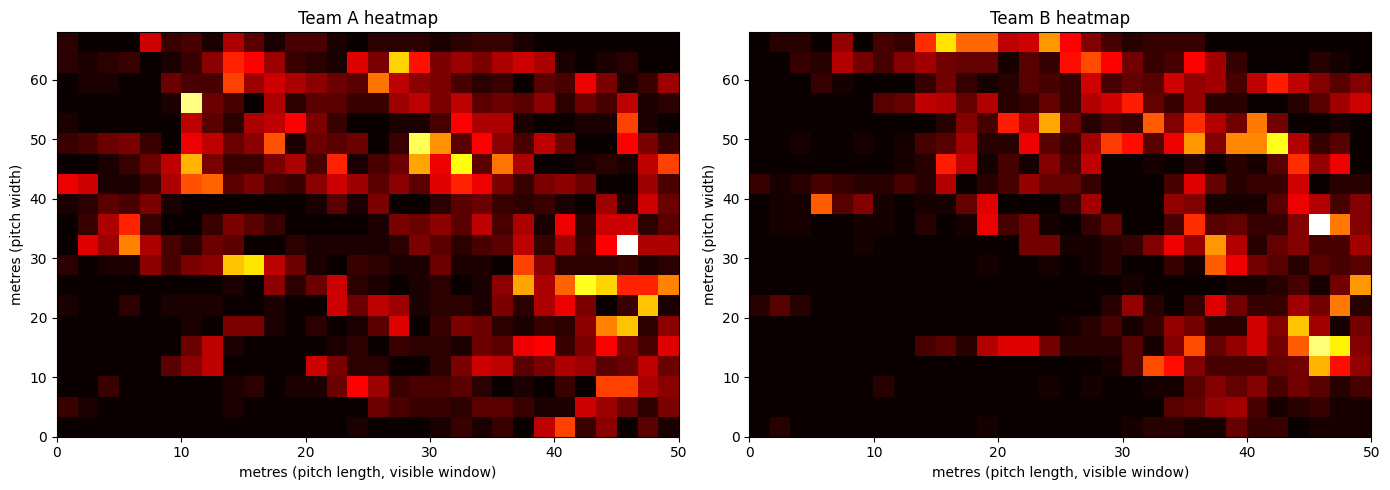

Passing network — 9 players, 7 edges
  P  3 -> P414   1 pass(es)
  P 19 -> P600   1 pass(es)
  P600 -> P422   1 pass(es)
  P761 -> P979   1 pass(es)
  P979 -> P761   1 pass(es)
  P761 -> P666   1 pass(es)
  P979 -> P620   1 pass(es)


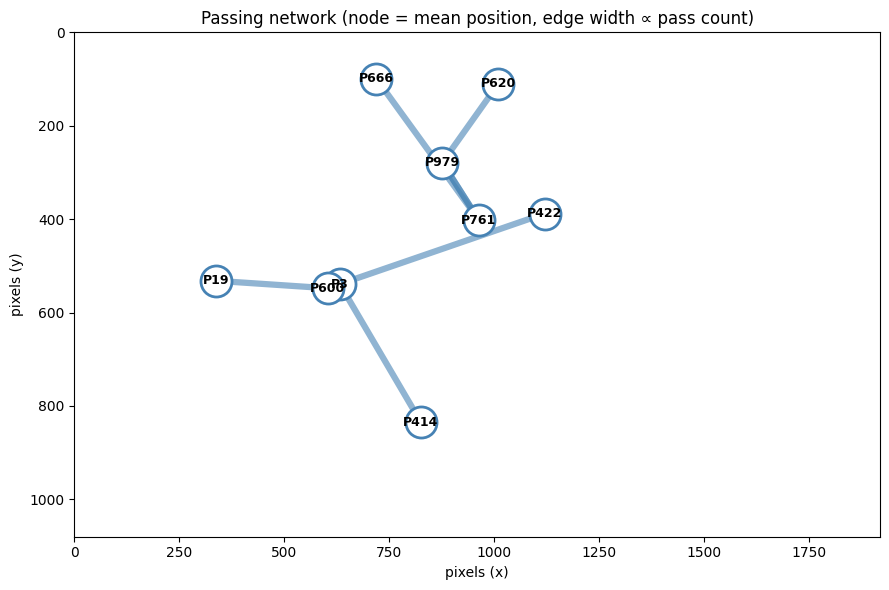

In [43]:
# ============================================================
# ⚽  HEATMAP + PASSING NETWORK (visual outputs, items 17–18)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

homography_store = HomographyStore(frame_homographies) if "frame_homographies" in globals() and frame_homographies else None
transformer = CoordinateTransformer(config, homography_store=homography_store)

# ── Heatmaps ───────────────────────────────────────────────────────────────
# [FIX] y-axis extent now uses pixel_to_meter_y (matching the scale
# to_pitch() actually applies to y-coordinates) instead of reusing the
# x-scale — previously this stretched/squashed the heatmap relative to a
# real pitch. See StatsConfig.pixel_to_meter_y / compute_heatmap.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, team, title in zip(axes, ("A", "B"), ("Team A heatmap", "Team B heatmap")):
    hm = compute_heatmap(tracking_data, transformer, config, team=team)
    if hm["hist"]:
        ax.imshow(np.array(hm["hist"]), origin="lower", cmap="hot", aspect="auto",
                  extent=[0, config.pitch_visible_m, 0, config.frame_h * config.pixel_to_meter_y])
    ax.set_title(title)
    ax.set_xlabel("metres (pitch length, visible window)")
    ax.set_ylabel("metres (pitch width)")
plt.tight_layout()
plt.show()

# ── Passing network ──────────────────────────────────────────────────────────
# [FIX] Previously text-only. Now also rendered as an actual network graph:
# nodes placed at each player's mean pass-involvement position (pitch
# pixels), edges drawn between passer/receiver with thickness proportional
# to pass count — this reads far more like a professional analytics output
# than a plain list.
net = results["passing_network"]
print(f"Passing network — {len(net['nodes'])} players, {len(net['edges'])} edges")
for e in sorted(net["edges"], key=lambda x: -x["weight"])[:10]:
    print(f"  P{e['from']:>3} -> P{e['to']:>3}   {e['weight']} pass(es)")

node_positions = net.get("node_positions", {})
edges = net.get("edges", [])

if node_positions and edges:
    fig, ax = plt.subplots(figsize=(9, 6))

    max_w = max(e["weight"] for e in edges)
    for e in edges:
        src, dst, w = e["from"], e["to"], e["weight"]
        if src not in node_positions or dst not in node_positions:
            continue
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.plot([x1, x2], [y1, y2], color="steelblue",
                linewidth=0.5 + 4.0 * (w / max_w), alpha=0.6, zorder=1)

    for node, (x, y) in node_positions.items():
        ax.scatter([x], [y], s=500, color="white", edgecolors="steelblue",
                   linewidths=2, zorder=2)
        ax.annotate(f"P{node}", (x, y), ha="center", va="center",
                    fontsize=9, fontweight="bold", zorder=3)

    ax.set_xlim(0, config.frame_w)
    ax.set_ylim(config.frame_h, 0)  # image-style y-axis (origin top-left)
    ax.set_title("Passing network (node = mean position, edge width ∝ pass count)")
    ax.set_xlabel("pixels (x)")
    ax.set_ylabel("pixels (y)")
    plt.tight_layout()
    plt.show()
else:
    print("  (No completed passes yet — passing network plot skipped.)")
